In [ ]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

In [ ]:
!wget -q https://dlcdn.apache.org/spark/spark-3.5.4/spark-3.5.4-bin-hadoop3.tgz

In [ ]:
!tar xf spark-3.5.4-bin-hadoop3.tgz

In [ ]:
import os
os.environ["JAVA_HOME"]="/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"]='/content/spark-3.5.4-bin-hadoop3'

In [ ]:
!pip install -q findspark
import findspark

In [ ]:
# findspark
findspark.init()
findspark.find()

'/content/spark-3.5.4-bin-hadoop3'

In [ ]:
from pyspark.sql.functions import col

In [ ]:
import pyspark

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load dataset
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName('Test2_DeathRiskFactor').getOrCreate()

df = spark.read.csv('/content/drive/My Drive/BDA/death_risk_factor.csv', header=True, inferSchema=True)

In [ ]:
df.show()

+-----------+----+-------------------+-----------------+---------------------------------+----------------------------------------+---------------------------+--------------------------+-------------+--------------+------------------------------+----------------+-----------+-----------+------------------+----------------------+-----------+---------------------+---------------------------+----------------------+--------------------+----------------------------+-----------+---------------+--------------------+------------------------+-------------+---------------------+-------------------+------------------------+--------------------------+
|     Entity|Year|Unsafe water source|Unsafe sanitation|No access to handwashing facility|Household air pollution from solid fuels|Non-exclusive breastfeeding|Discontinued breastfeeding|Child wasting|Child stunting|Low birth weight for gestation|Secondhand smoke|Alcohol use|   Drug use|Diet low in fruits|Diet low in vegetables| Unsafe sex|Low physical

###Exploring The Data for Values in Malaysia and Neigboring Countries

In [ ]:
# Filter dataset to contain Malaysia and neighboring countries
countries = ["Malaysia", "Indonesia", "Thailand", "Singapore", "Brunei", "Philippines"]
filtered_df = df.filter(df["Entity"].isin(countries))

In [ ]:
df1 = filtered_df

In [ ]:
# Show a preview of the data
df1.show()

+------+----+-------------------+-----------------+---------------------------------+----------------------------------------+---------------------------+--------------------------+-------------+--------------+------------------------------+----------------+-----------+-----------+------------------+----------------------+-----------+---------------------+---------------------------+----------------------+--------------------+----------------------------+-----------+---------------+--------------------+------------------------+-------------+---------------------+-------------------+------------------------+--------------------------+
|Entity|Year|Unsafe water source|Unsafe sanitation|No access to handwashing facility|Household air pollution from solid fuels|Non-exclusive breastfeeding|Discontinued breastfeeding|Child wasting|Child stunting|Low birth weight for gestation|Secondhand smoke|Alcohol use|   Drug use|Diet low in fruits|Diet low in vegetables| Unsafe sex|Low physical activity|

Handle missing values

In [ ]:
from pyspark.sql.functions import col, sum

# Calculate the count of missing values per column
missing_values = df1.select(
    [sum(col(c).isNull().cast("int")).alias(c) for c in df1.columns]
)

# Show missing values
missing_values.show()

+------+----+-------------------+-----------------+---------------------------------+----------------------------------------+---------------------------+--------------------------+-------------+--------------+------------------------------+----------------+-----------+--------+------------------+----------------------+----------+---------------------+---------------------------+----------------------+--------------------+----------------------------+-------+---------------+--------------------+------------------------+-------------+---------------------+-------------------+------------------------+--------------------------+
|Entity|Year|Unsafe water source|Unsafe sanitation|No access to handwashing facility|Household air pollution from solid fuels|Non-exclusive breastfeeding|Discontinued breastfeeding|Child wasting|Child stunting|Low birth weight for gestation|Secondhand smoke|Alcohol use|Drug use|Diet low in fruits|Diet low in vegetables|Unsafe sex|Low physical activity|High fasting

In [ ]:
from pyspark.sql import Window
from pyspark.sql.functions import last
import sys

# Define the window specification for forward fill
window = Window.partitionBy('Entity')\
               .orderBy('Year')\
               .rowsBetween(-sys.maxsize, 0)  # Fill forward

# Apply forward fill to column 'High Total Cholesterol'
df_filled = df1.withColumn('High Total Cholesterol',
                           last('High Total Cholesterol', ignorenulls=True).over(window))

# Show the results
df_filled.show(10)

+------+----+-------------------+-----------------+---------------------------------+----------------------------------------+---------------------------+--------------------------+-------------+--------------+------------------------------+----------------+-----------+-----------+------------------+----------------------+-----------+---------------------+---------------------------+----------------------+--------------------+----------------------------+-----------+---------------+--------------------+------------------------+-------------+---------------------+-------------------+------------------------+--------------------------+
|Entity|Year|Unsafe water source|Unsafe sanitation|No access to handwashing facility|Household air pollution from solid fuels|Non-exclusive breastfeeding|Discontinued breastfeeding|Child wasting|Child stunting|Low birth weight for gestation|Secondhand smoke|Alcohol use|   Drug use|Diet low in fruits|Diet low in vegetables| Unsafe sex|Low physical activity|

In [ ]:
df1 = df_filled

EDA

1. For Each Year, What Factor Contributes the Most?

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# List of risk factor columns (excluding 'Entity' and 'Year')
risk_factors = [col for col in df1.columns if col not in ['Entity', 'Year']]

# Create a column to identify the maximum risk factor value for each year
df1_with_max = (
    df1.withColumn("max_value", F.greatest(*[F.col(col) for col in risk_factors]))  # Identify max value across columns
)

# Create a new column to find the corresponding factor for the max value
df1_with_max = df1_with_max.withColumn(
    "max_factor",
    F.expr(f"""
        CASE
        {' '.join([f"WHEN `{col}` = max_value THEN '{col}'" for col in risk_factors])}
        ELSE NULL END
    """)
)

# Optionally, you can drop intermediate columns if not needed
df1_with_max = df1_with_max.select("Year", "Entity", "max_value", "max_factor")

In [ ]:
df1_with_max.show(truncate=False)

+----+------+-----------+---------------------------+
|Year|Entity|max_value  |max_factor                 |
+----+------+-----------+---------------------------+
|1990|Brunei|225.2499035|High fasting plasma glucose|
|1991|Brunei|226.4326844|High fasting plasma glucose|
|1992|Brunei|226.1819173|High fasting plasma glucose|
|1993|Brunei|225.1911888|High fasting plasma glucose|
|1994|Brunei|224.9677937|High fasting plasma glucose|
|1995|Brunei|223.9106452|High fasting plasma glucose|
|1996|Brunei|222.9081513|High fasting plasma glucose|
|1997|Brunei|222.6455963|High fasting plasma glucose|
|1998|Brunei|227.1443064|High fasting plasma glucose|
|1999|Brunei|231.6556403|High fasting plasma glucose|
|2000|Brunei|238.3455284|High fasting plasma glucose|
|2001|Brunei|244.9132682|High fasting plasma glucose|
|2002|Brunei|252.471273 |High fasting plasma glucose|
|2003|Brunei|260.9209055|High fasting plasma glucose|
|2004|Brunei|269.0574865|High fasting plasma glucose|
|2005|Brunei|277.2503584|Hig

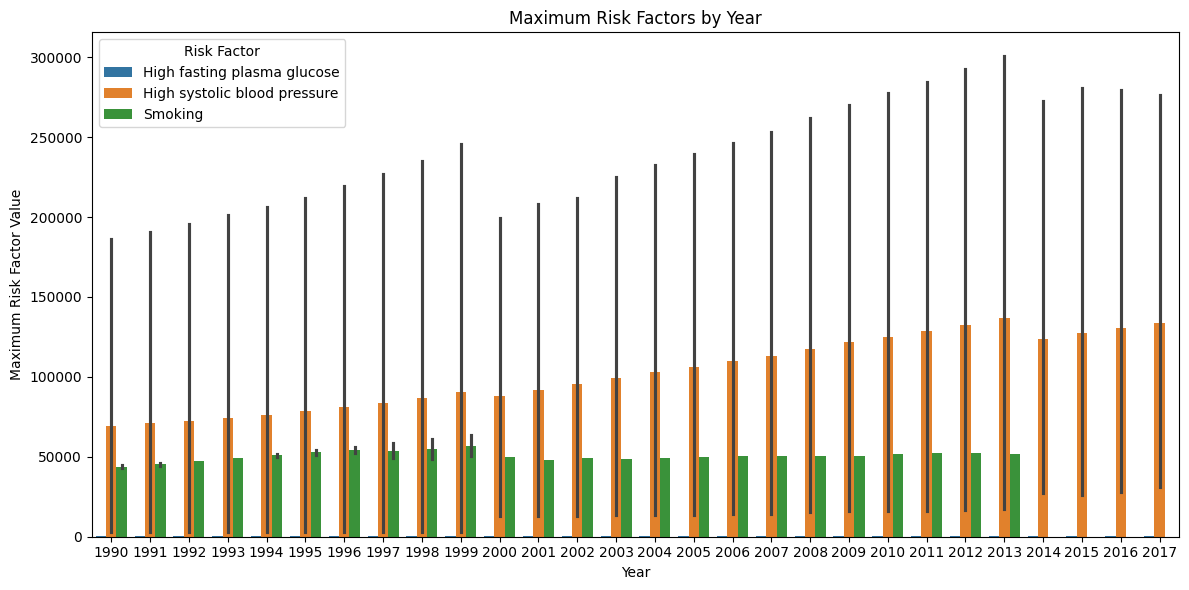

In [ ]:
pandas_df = df1_with_max.toPandas()
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=pandas_df,
    x="Year",
    y="max_value",
    hue="max_factor"
)

# Customize the plot
plt.title("Maximum Risk Factors by Year")
plt.xlabel("Year")
plt.ylabel("Maximum Risk Factor Value")
plt.legend(title="Risk Factor")
plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px

fig = px.bar(
    pandas_df,
    x="Year",
    y="max_value",
    color="max_factor",
    hover_data=["Entity"],
    title="Maximum Risk Factors by Year",
    labels={"max_value": "Risk Factor Value", "max_factor": "Risk Factor"}
)
fig.show()

2. What is the most common factor?

In [ ]:
# Compute average for each risk factor across years and entities
avg_df = df1.agg(
    *[F.avg(factor).alias(f"avg_{factor}") for factor in risk_factors]
)

# Show the average for each risk factor
avg_df.show()

# Identify the most common factor by finding the one with the highest average value
most_common_factor = avg_df.collect()[0].asDict()
most_common_factor_name = max(most_common_factor, key=most_common_factor.get)  # This gives you the factor with the highest average value

print(f"The most common factor is: {most_common_factor_name}")

+-----------------------+---------------------+-------------------------------------+--------------------------------------------+-------------------------------+------------------------------+------------------+------------------+----------------------------------+--------------------+------------------+------------------+----------------------+--------------------------+-----------------+-------------------------+-------------------------------+--------------------------+------------------------+--------------------------------+------------------+-------------------+------------------------+----------------------------+------------------+-------------------------+-----------------------+----------------------------+------------------------------+
|avg_Unsafe water source|avg_Unsafe sanitation|avg_No access to handwashing facility|avg_Household air pollution from solid fuels|avg_Non-exclusive breastfeeding|avg_Discontinued breastfeeding| avg_Child wasting|avg_Child stunting|avg_Low bi

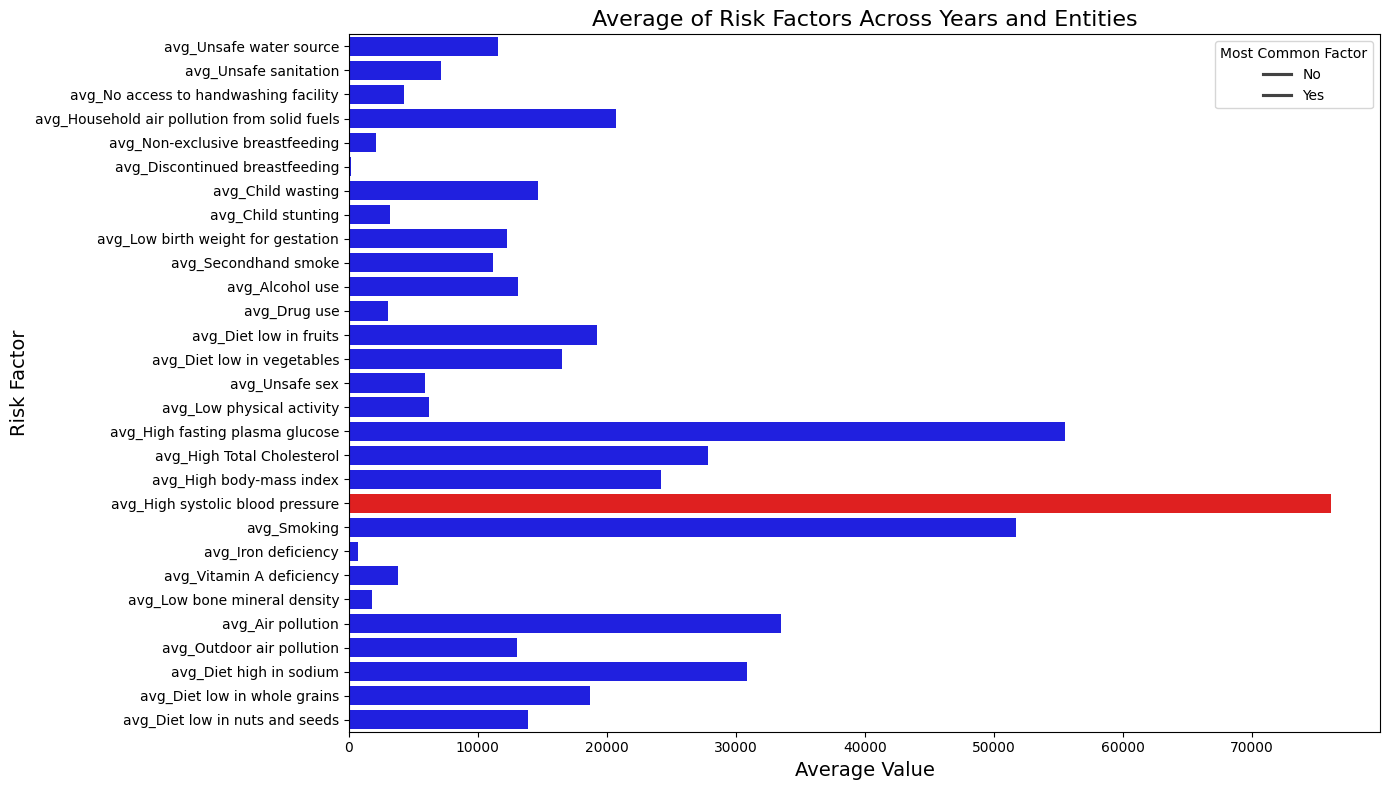

In [ ]:
# Convert the Spark DataFrame (avg_df) to Pandas for visualization
avg_pandas_df = avg_df.toPandas()

# Reshape the DataFrame for plotting
avg_pandas_df = avg_pandas_df.melt(
    var_name="Risk Factor",
    value_name="Average"
)

# Add a column to indicate whether the factor is the most common
avg_pandas_df["Is Most Common"] = avg_pandas_df["Risk Factor"] == most_common_factor_name

# Plot graph
plt.figure(figsize=(14, 8))
sns.barplot(
    data=avg_pandas_df,
    y="Risk Factor",
    x="Average",
    hue="Is Most Common",
    dodge=False,  # Ensure bars don't split into separate hues
    palette={True: "red", False: "blue"}
)

plt.title("Average of Risk Factors Across Years and Entities", fontsize=16)
plt.xlabel("Average Value", fontsize=14)
plt.ylabel("Risk Factor", fontsize=14)
plt.legend(title="Most Common Factor", labels=["No", "Yes"], loc="upper right")
plt.tight_layout()
plt.show()

How do risk factors trend over time for different countries?

In [ ]:
# Filter the dataset to include only Malaysia and its neighbors
countries = ["Malaysia", "Singapore", "Thailand", "Indonesia", "Brunei", "Philippines"]
df_filtered = df1.filter(df1["Entity"].isin(countries))

risk_factors = [col for col in df1.columns if col not in ['Entity', 'Year']]

# Group by 'Entity' (country) and 'Year', and calculate the average for each risk factor
df_trends = df_filtered.groupBy("Entity", "Year").agg(
    *[F.avg(factor).alias(f"avg_{factor}") for factor in risk_factors]
)

# Show the trends
df_trends.show(10)

+------+----+-----------------------+---------------------+-------------------------------------+--------------------------------------------+-------------------------------+------------------------------+-----------------+------------------+----------------------------------+--------------------+---------------+------------+----------------------+--------------------------+--------------+-------------------------+-------------------------------+--------------------------+------------------------+--------------------------------+-----------+-------------------+------------------------+----------------------------+-----------------+-------------------------+-----------------------+----------------------------+------------------------------+
|Entity|Year|avg_Unsafe water source|avg_Unsafe sanitation|avg_No access to handwashing facility|avg_Household air pollution from solid fuels|avg_Non-exclusive breastfeeding|avg_Discontinued breastfeeding|avg_Child wasting|avg_Child stunting|avg_Low 

<Figure size 1200x800 with 0 Axes>

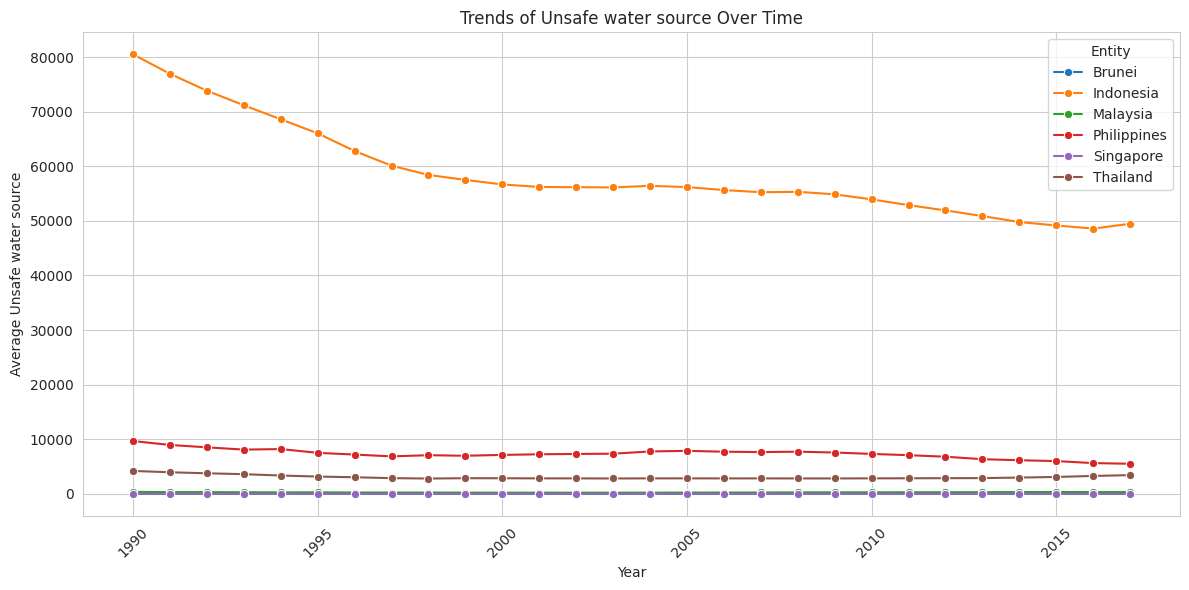

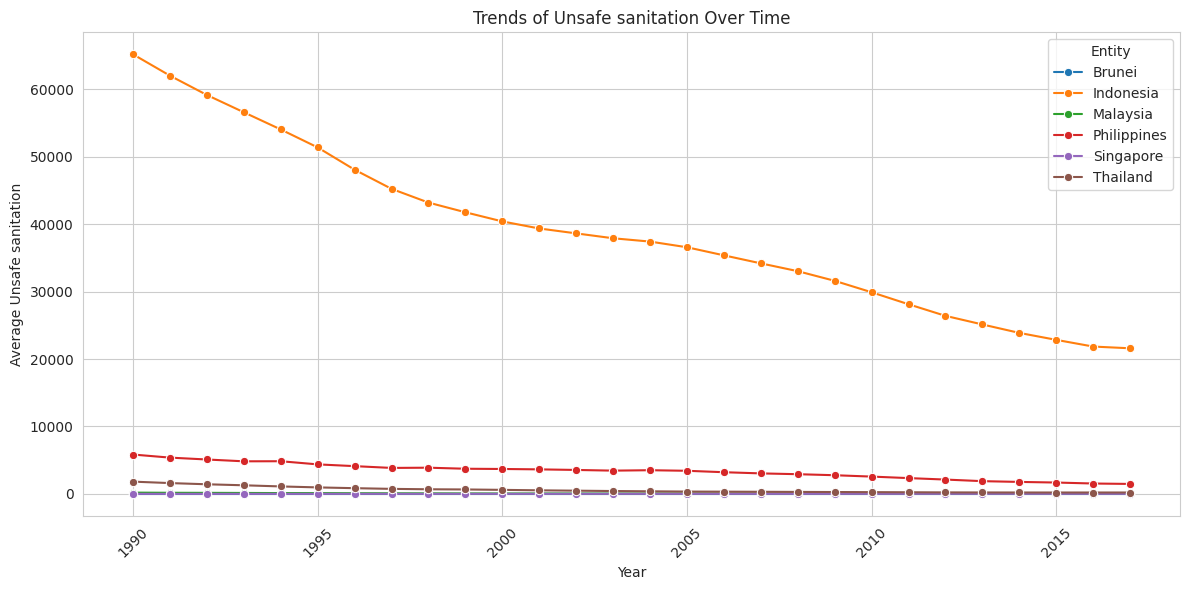

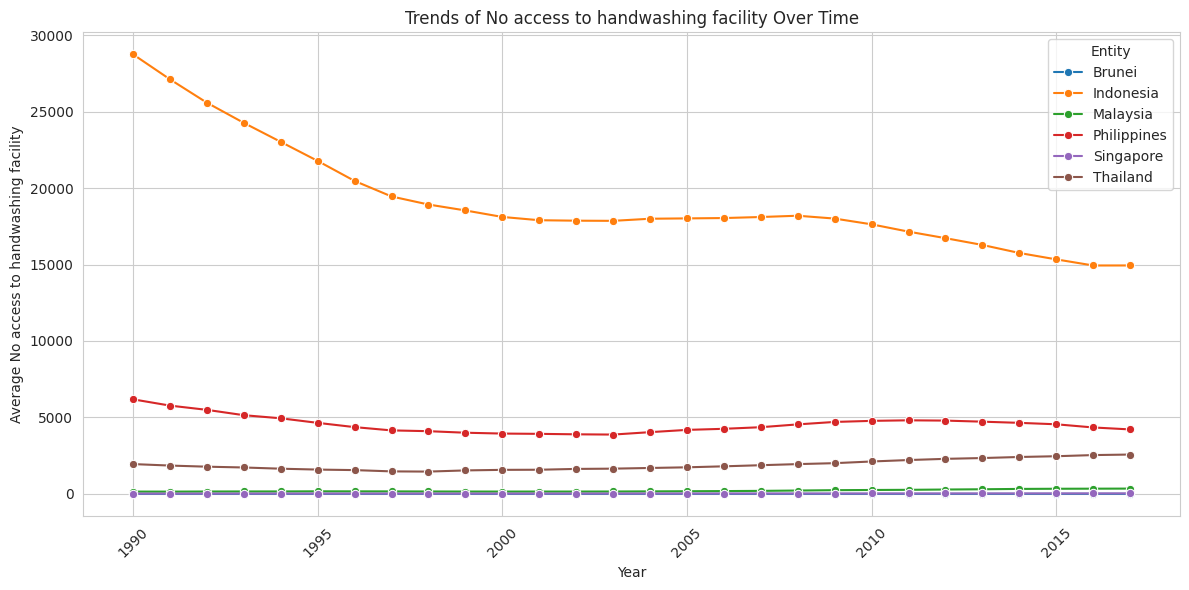

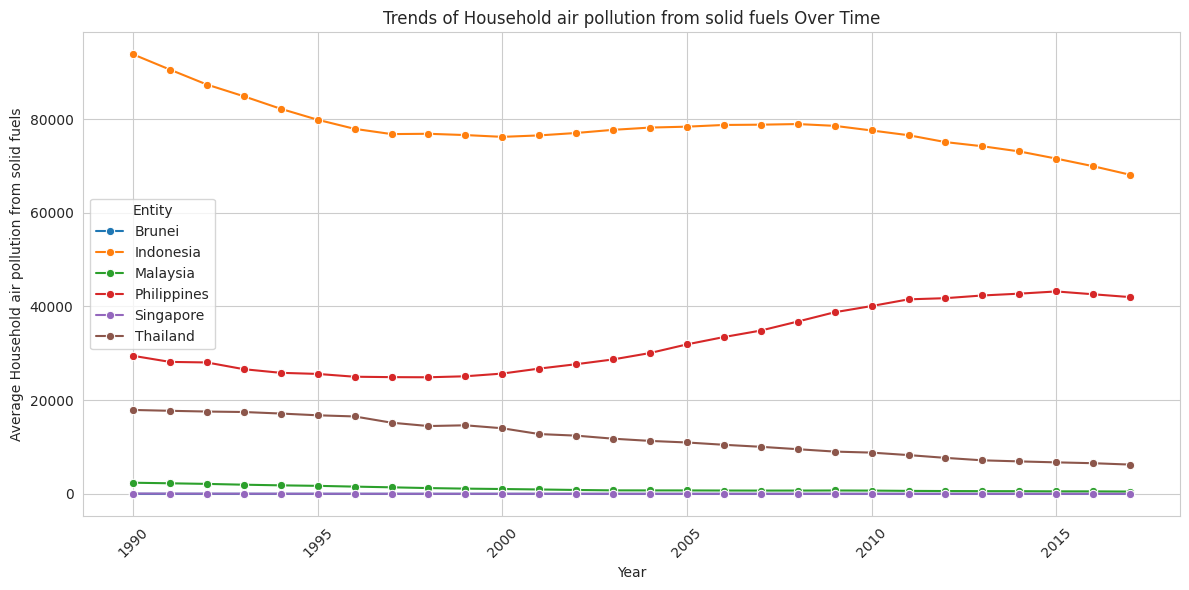

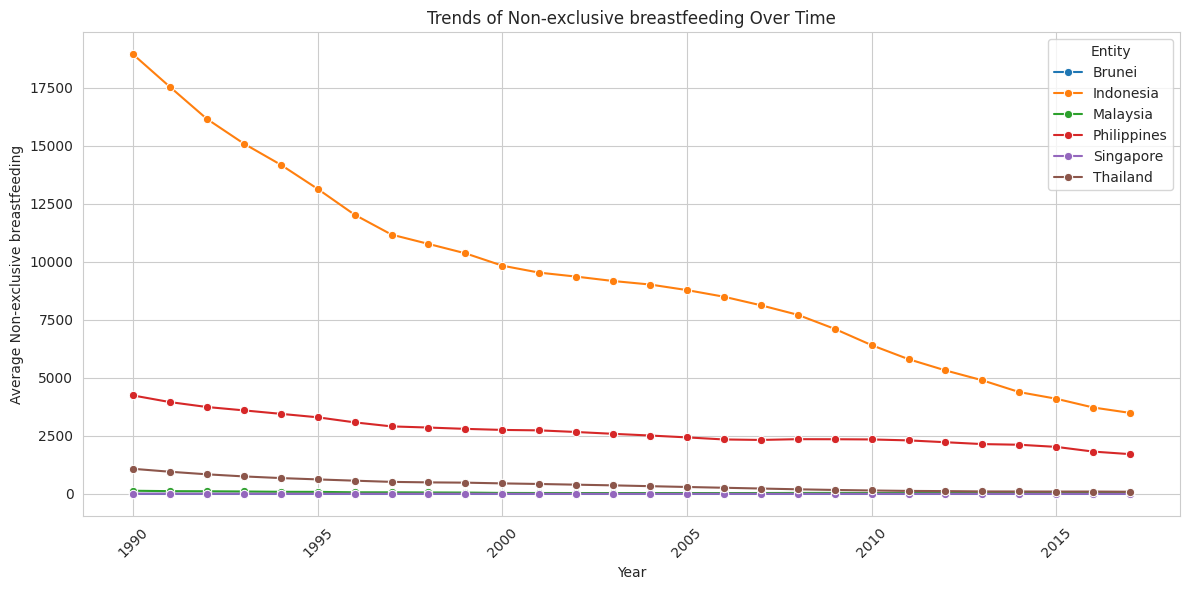

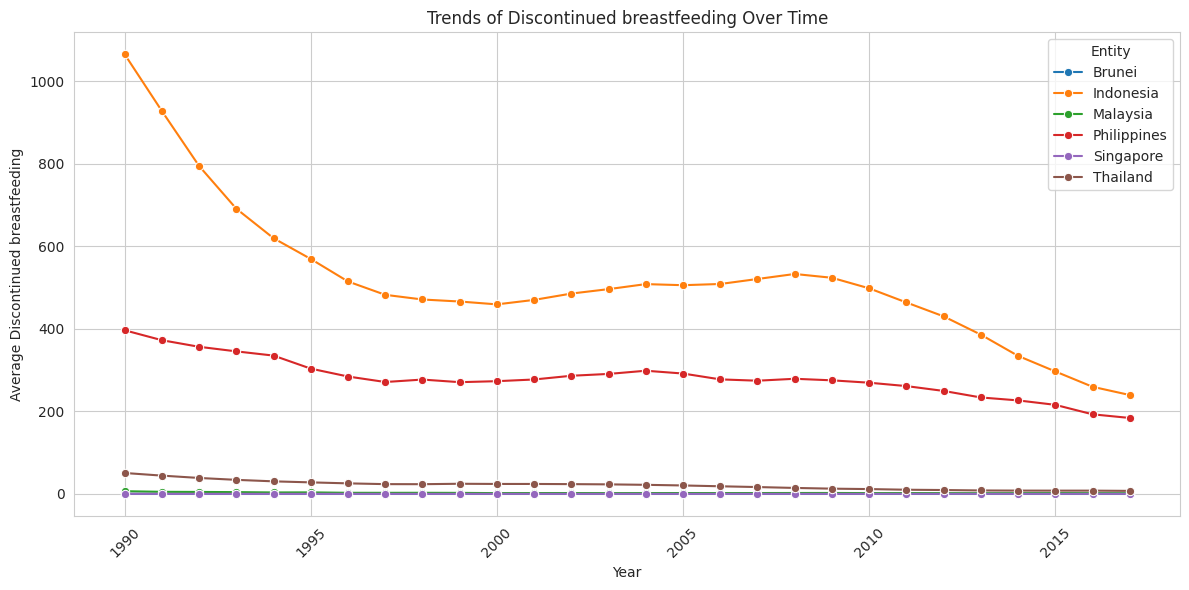

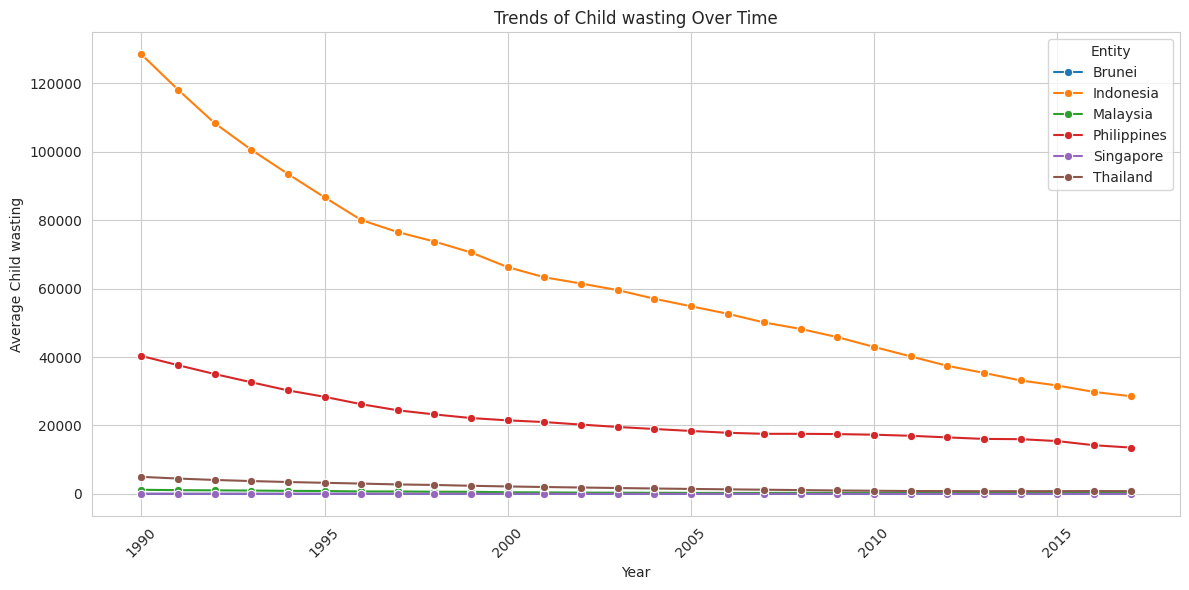

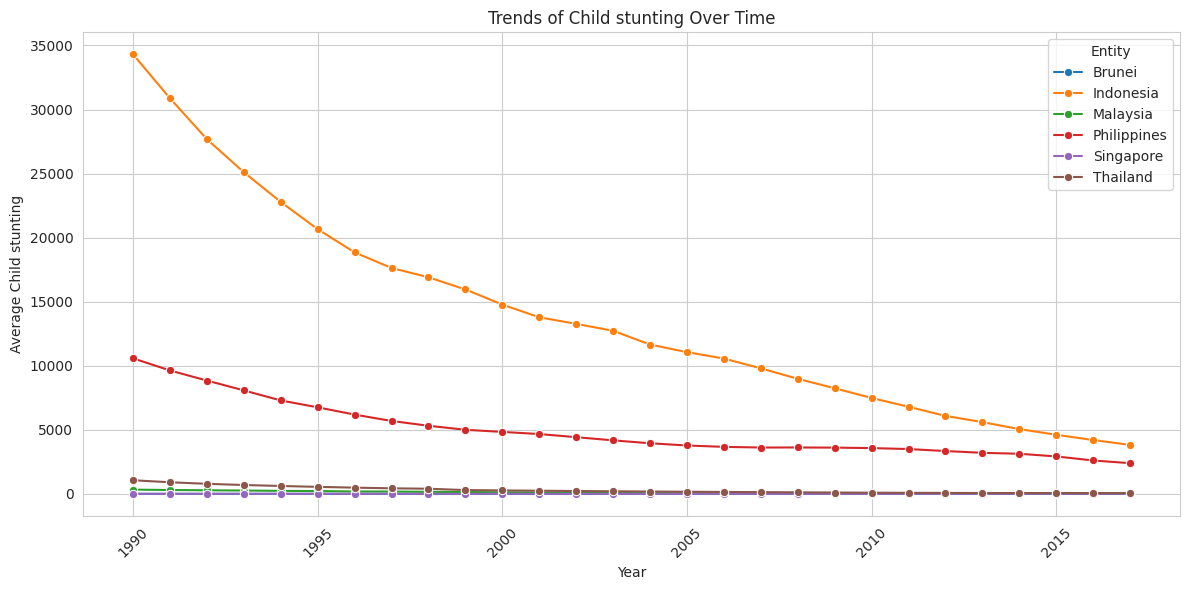

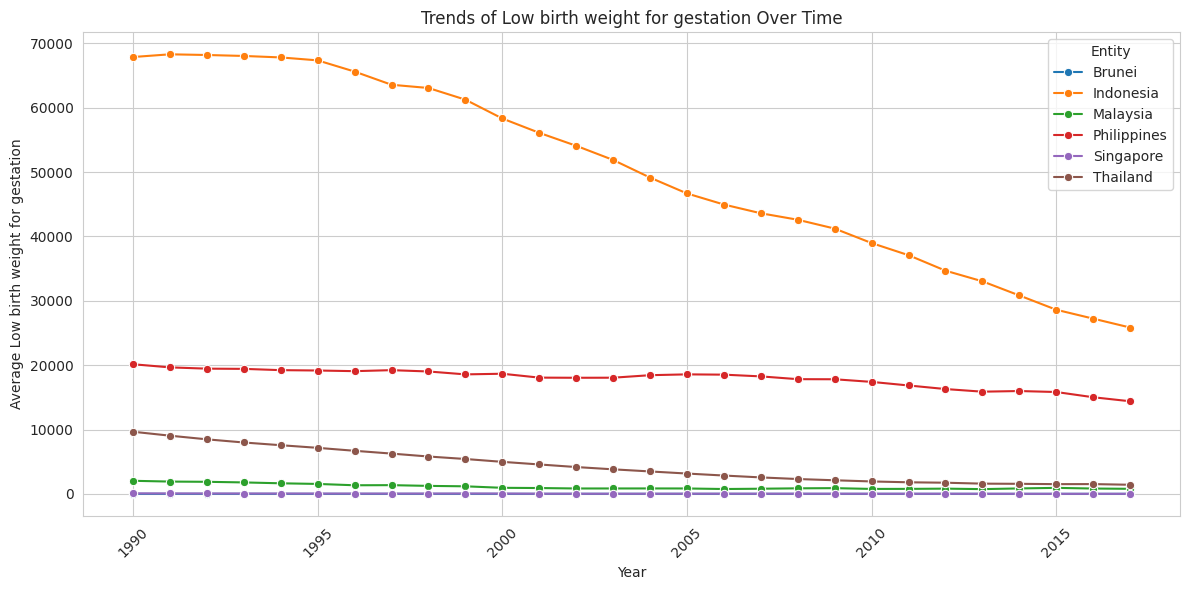

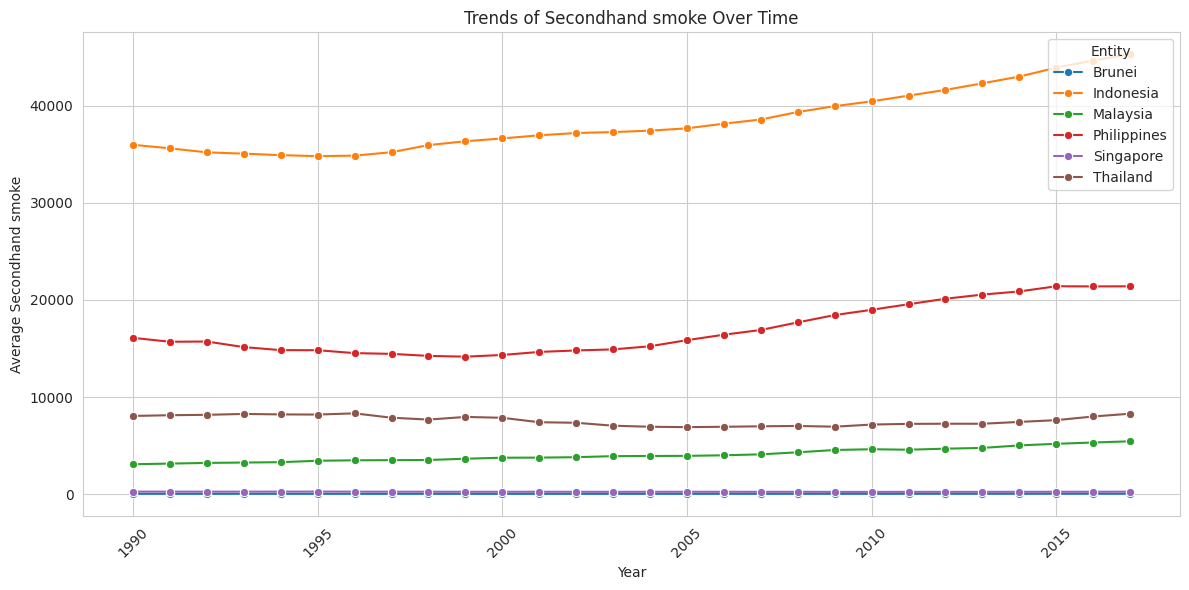

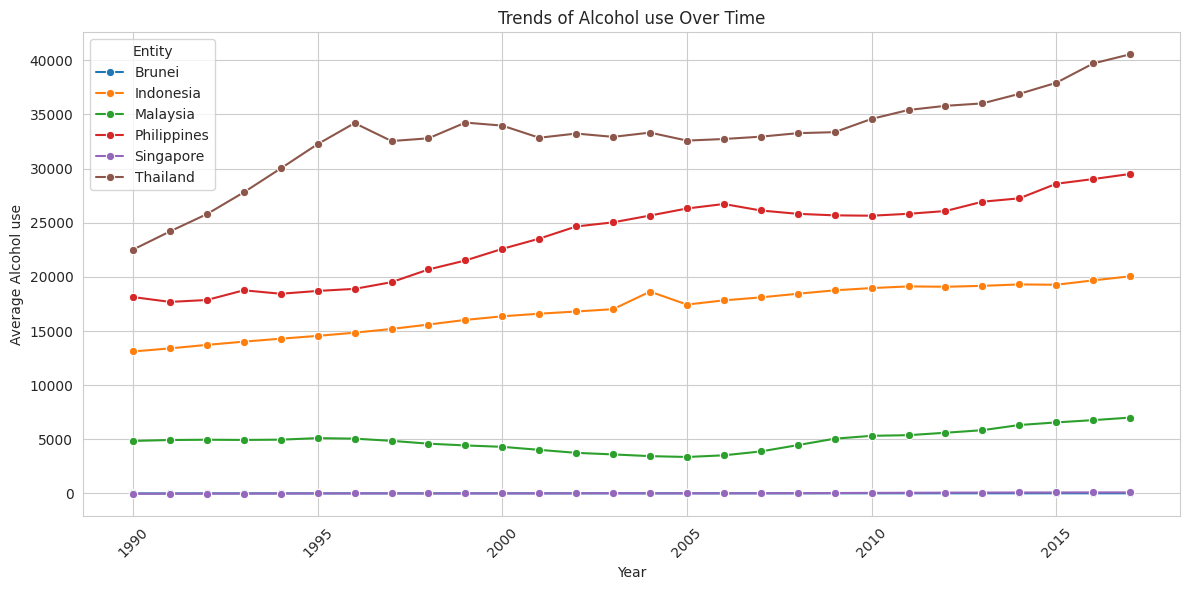

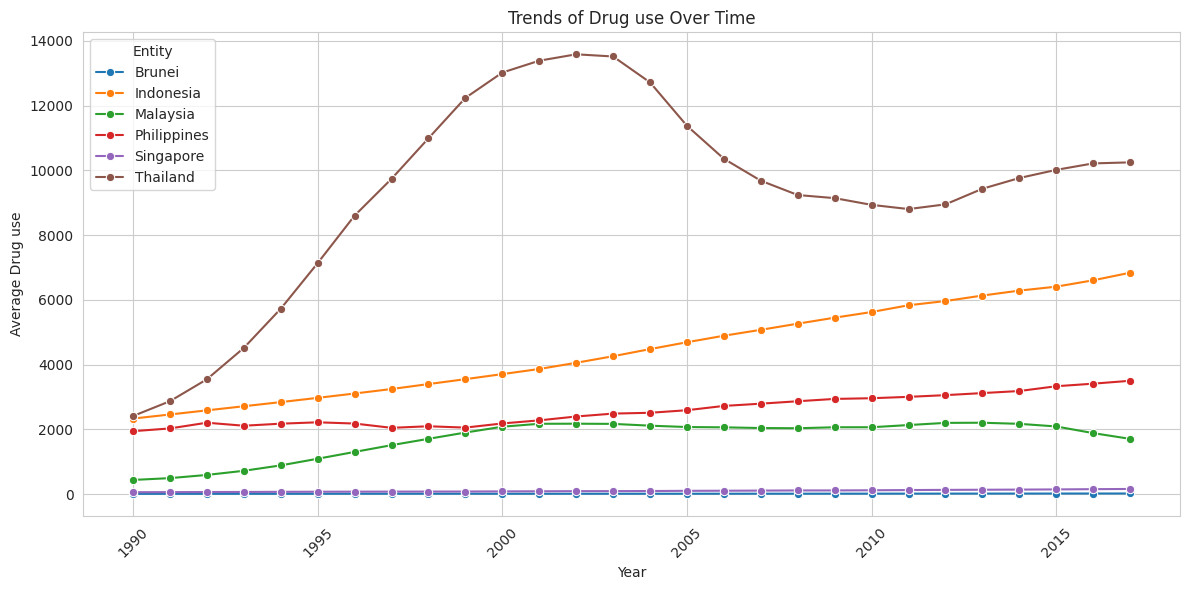

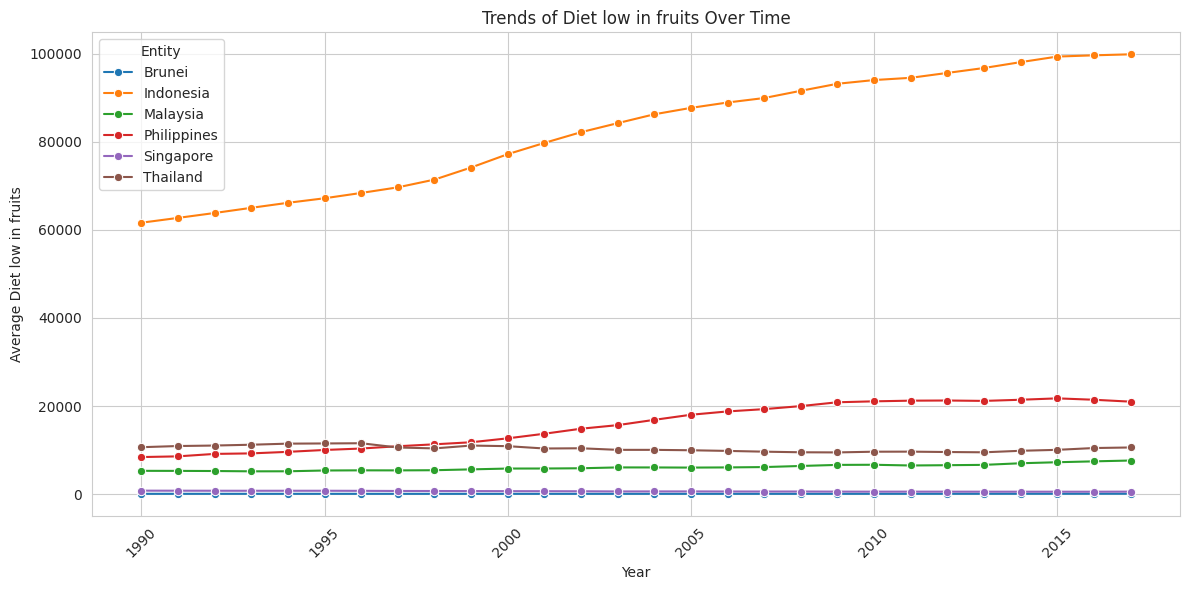

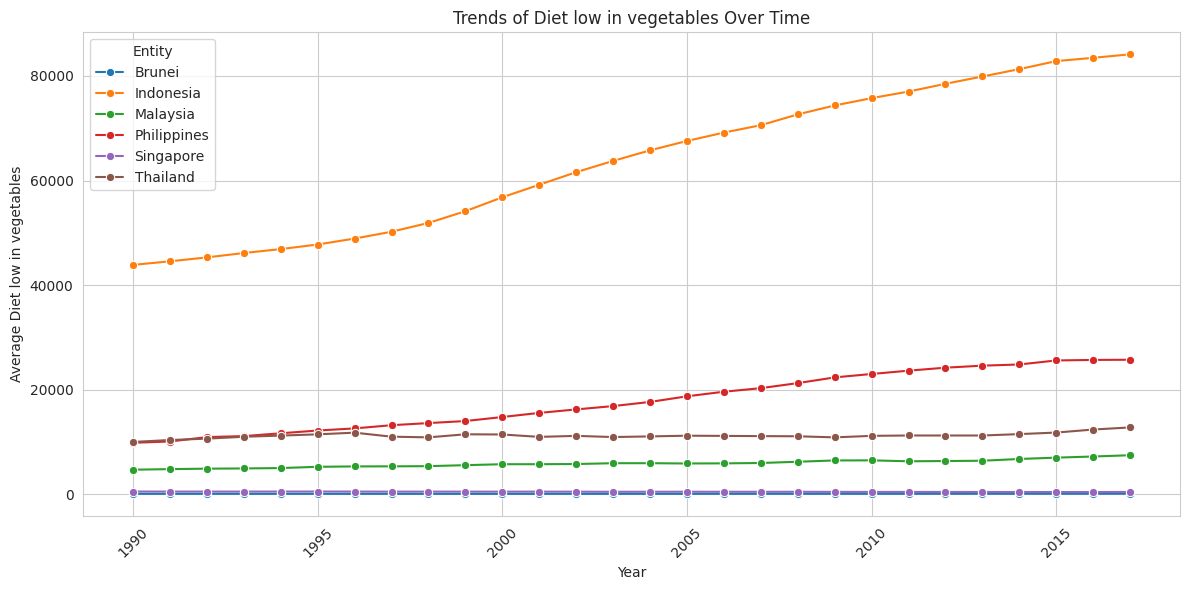

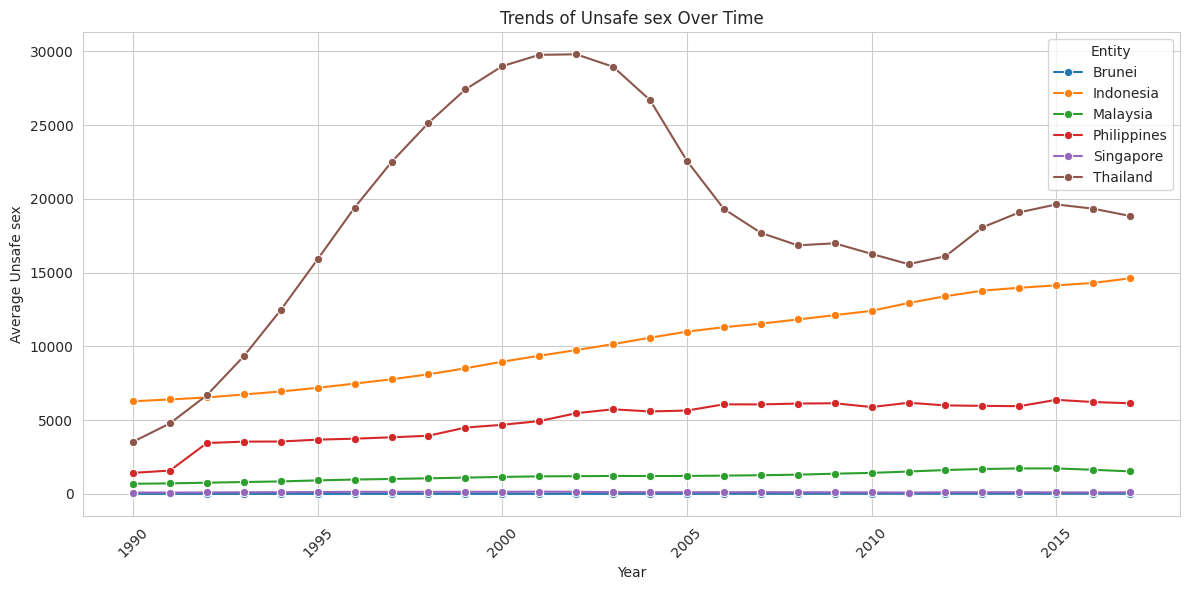

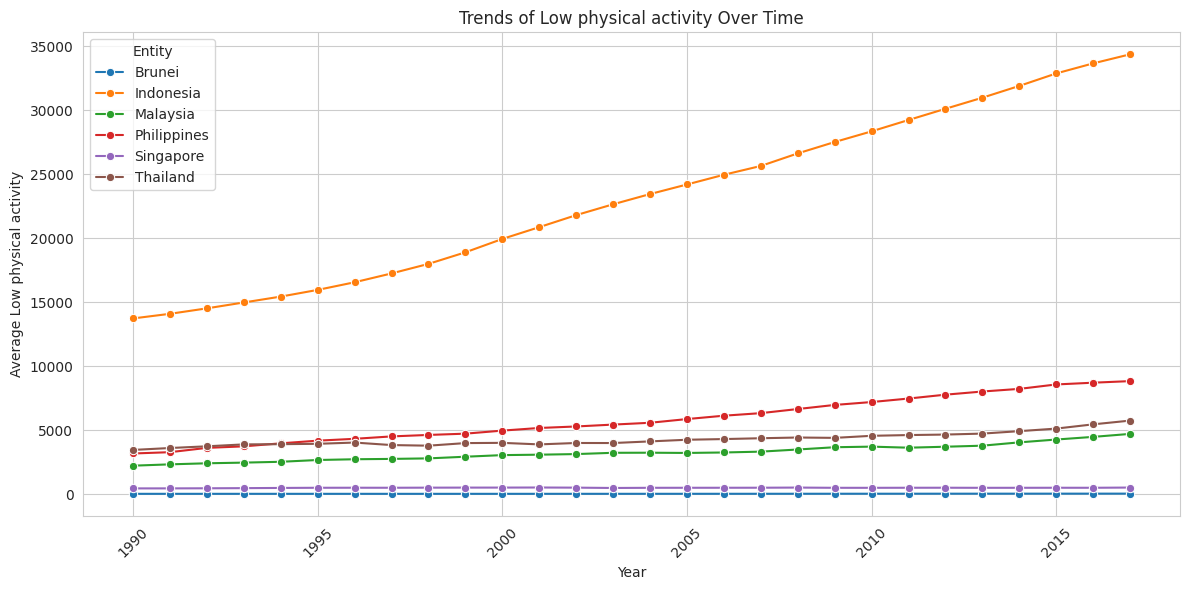

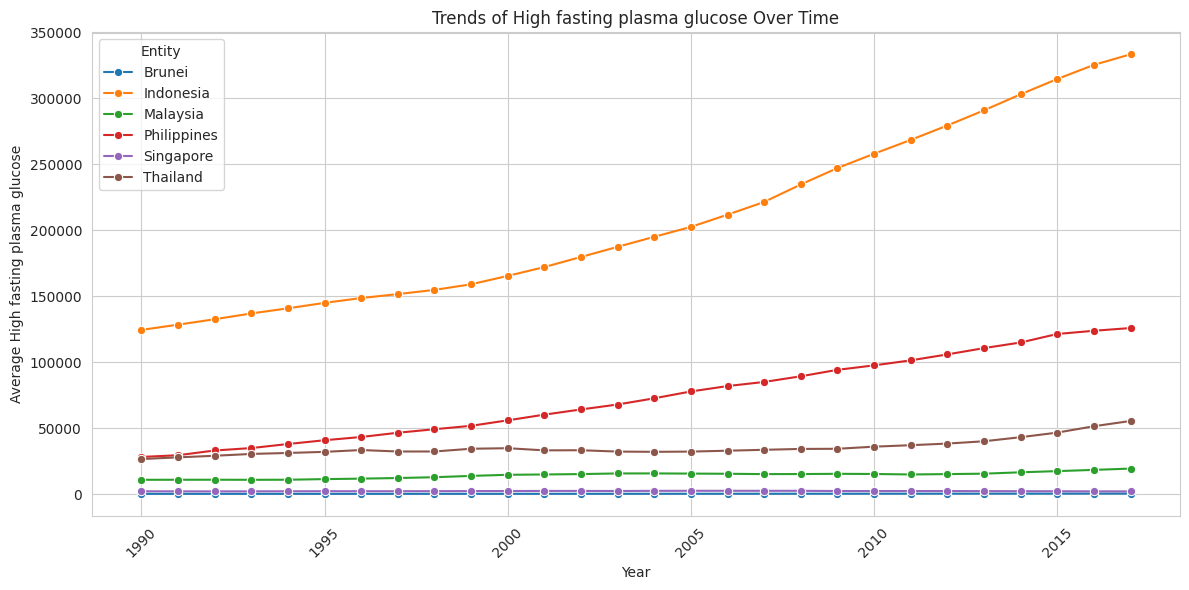

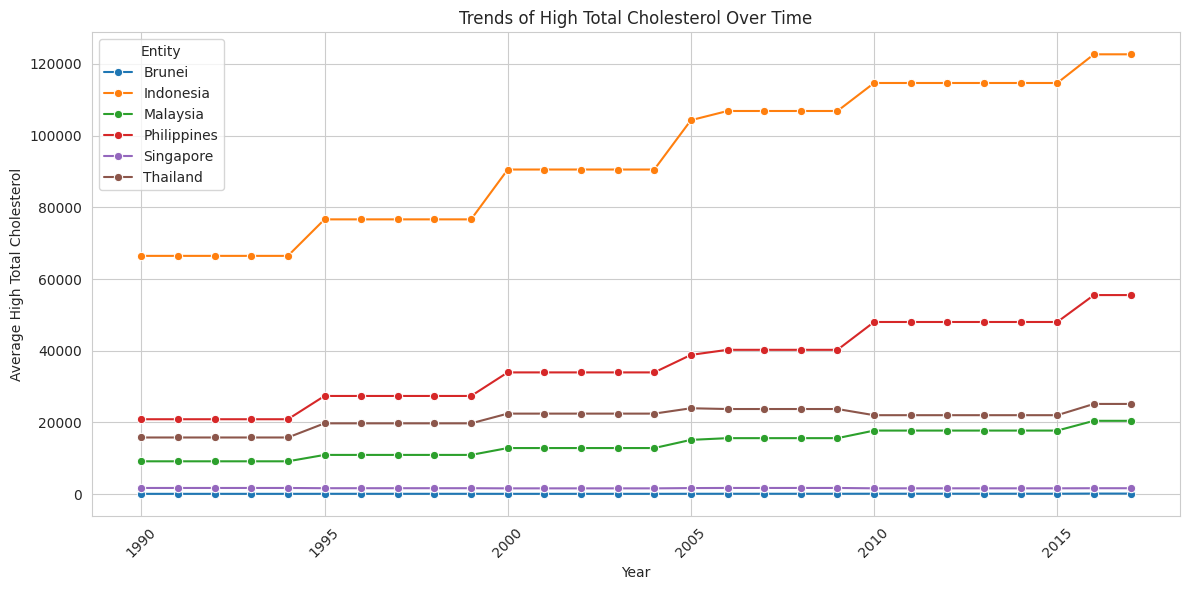

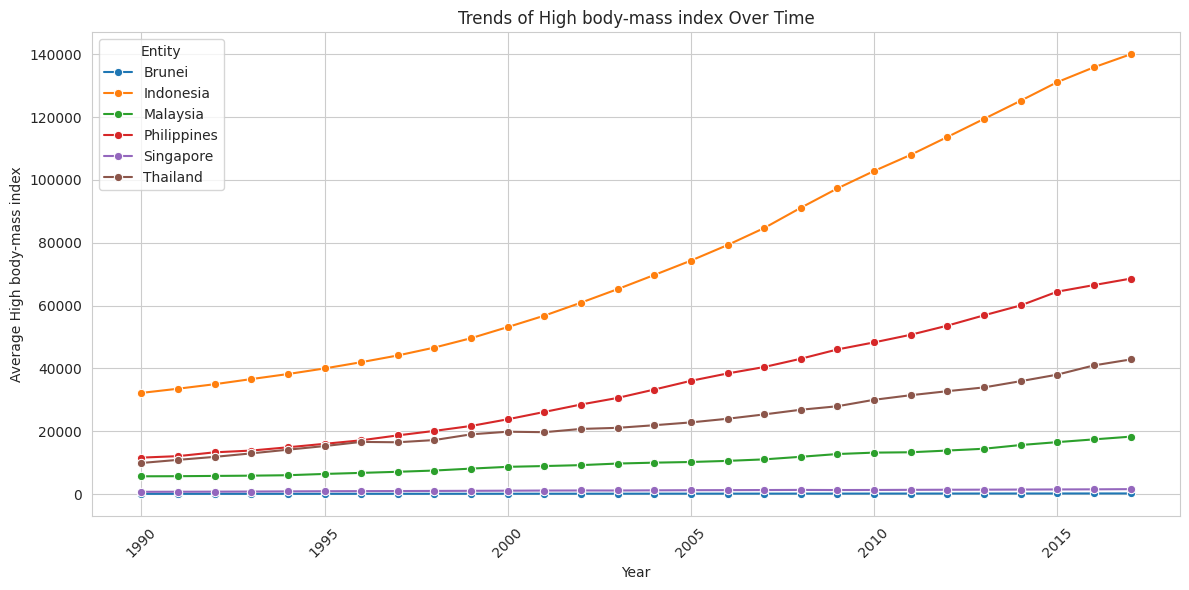

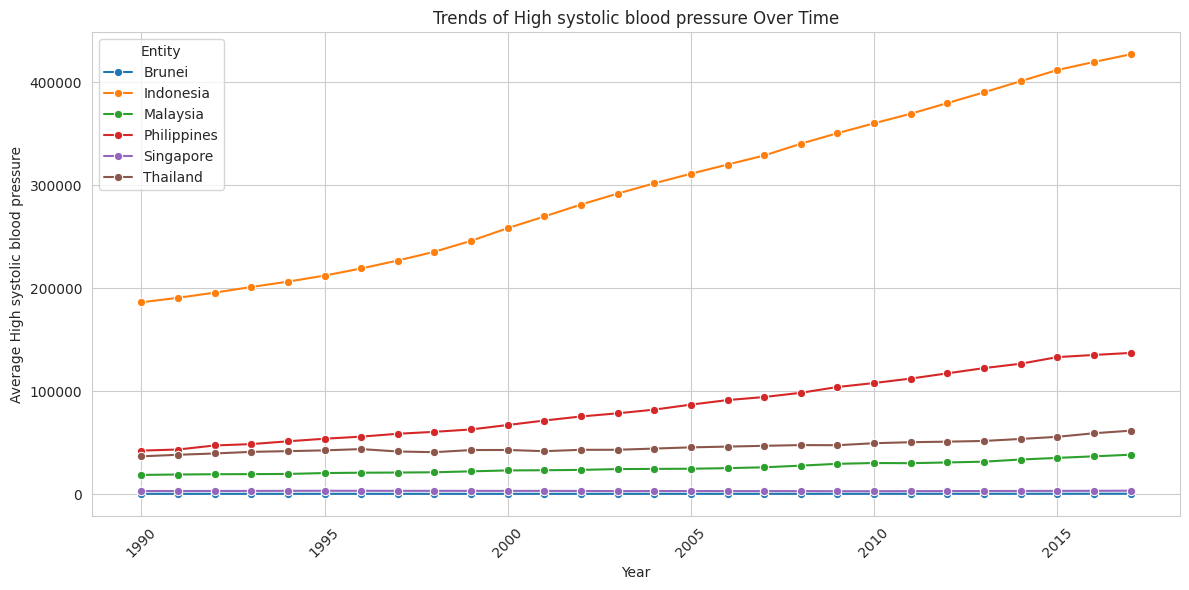

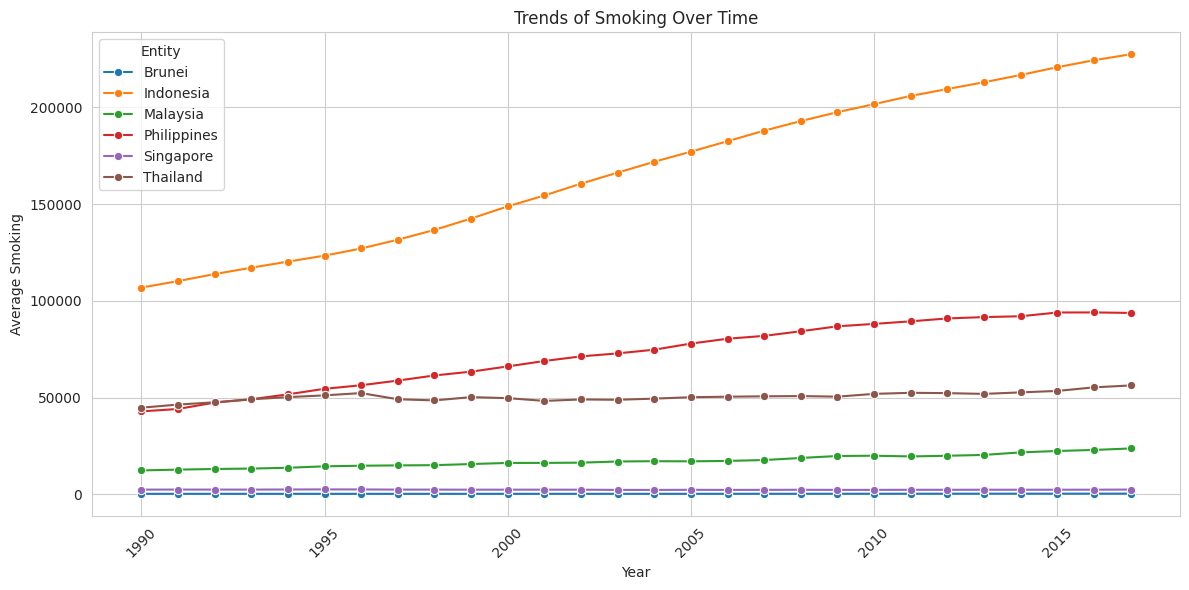

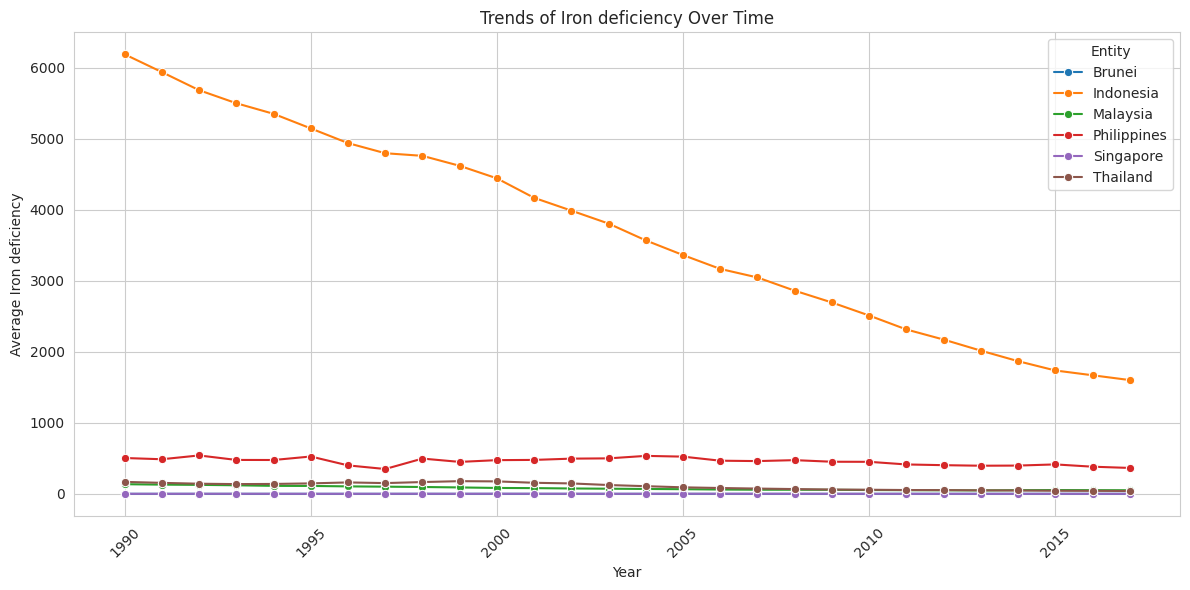

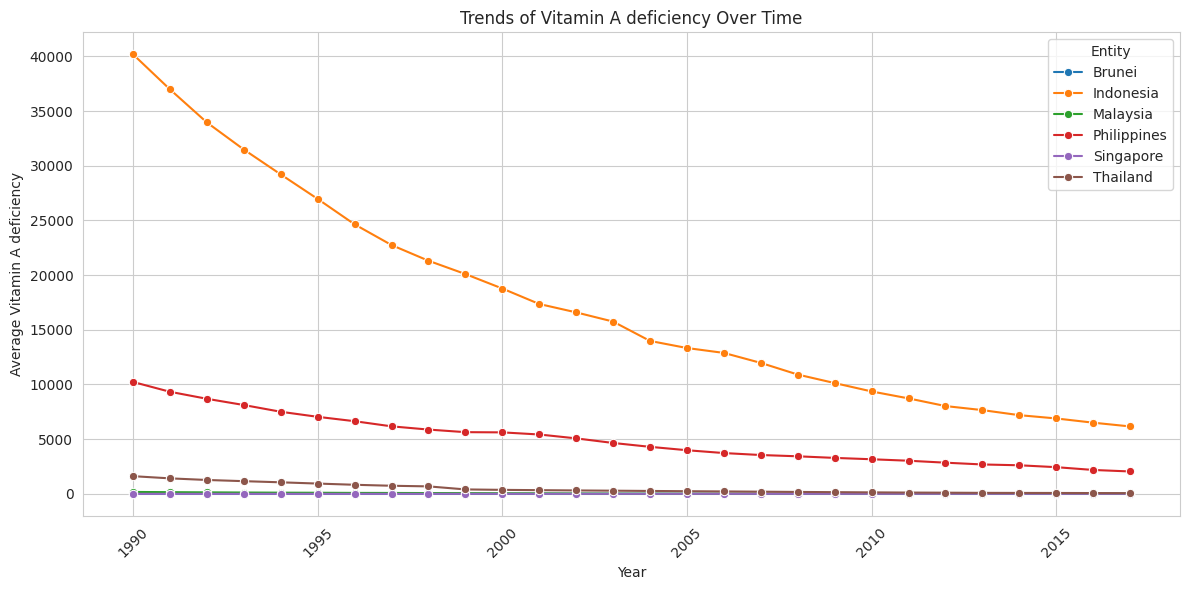

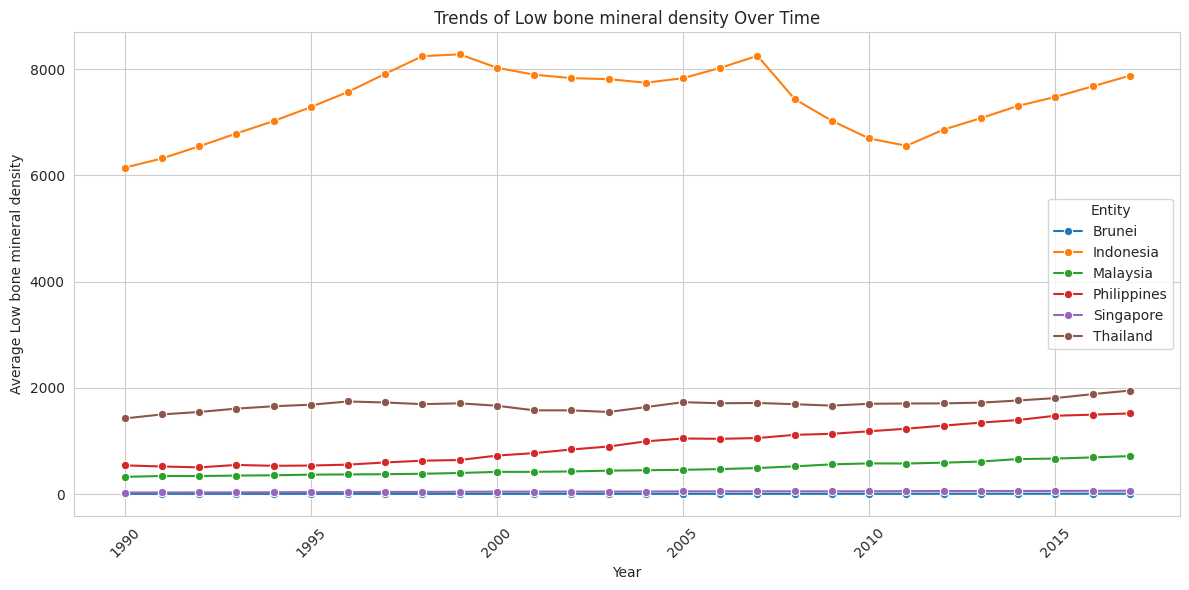

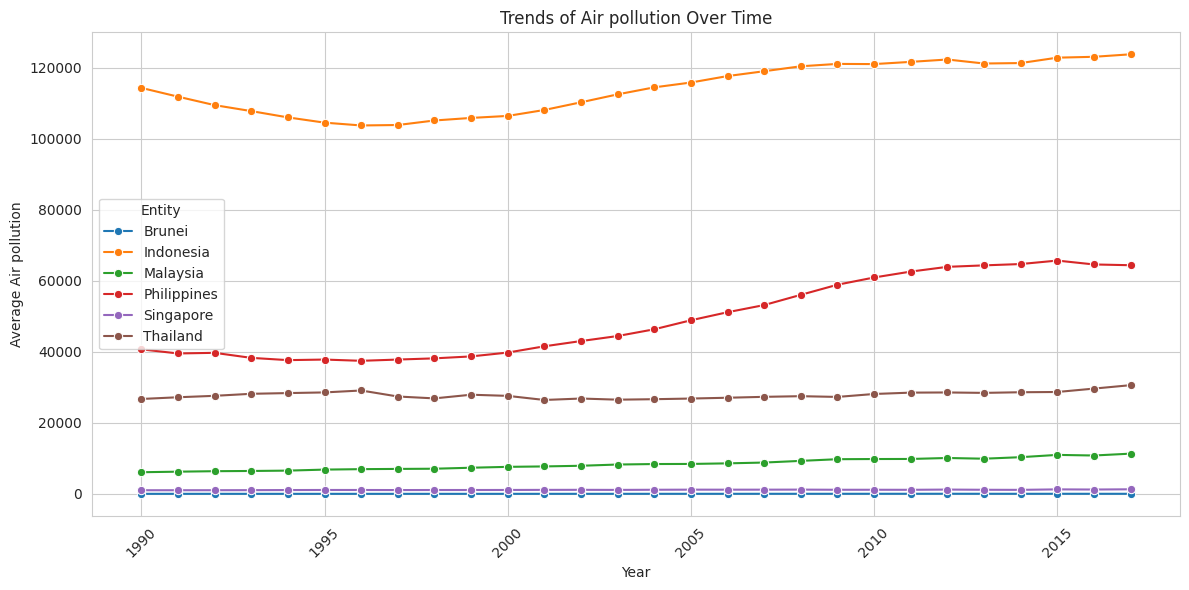

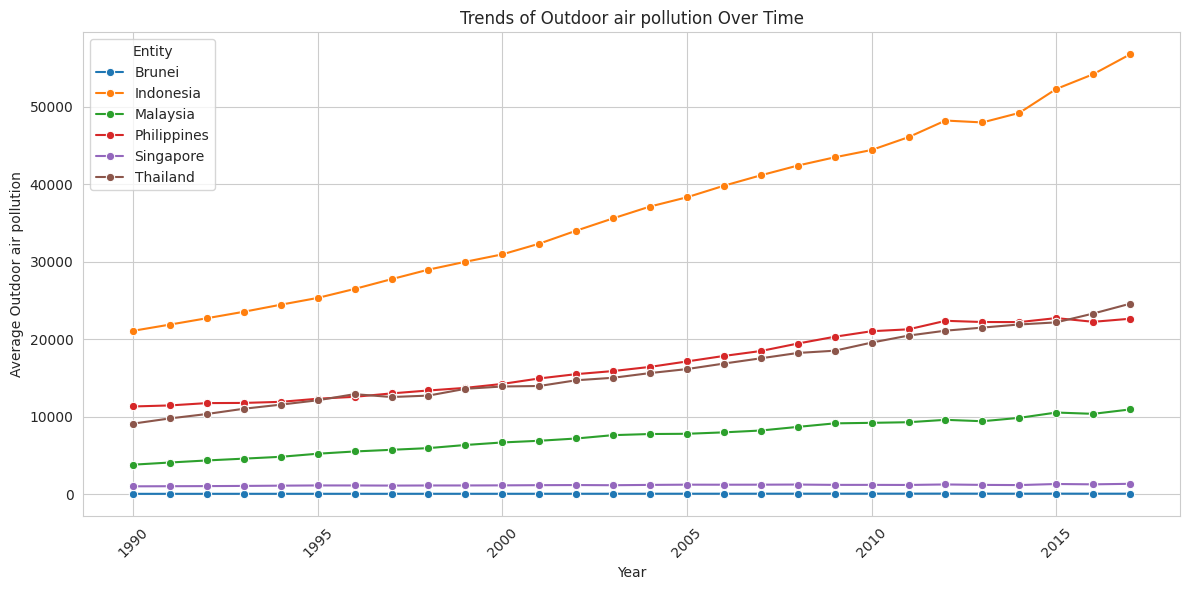

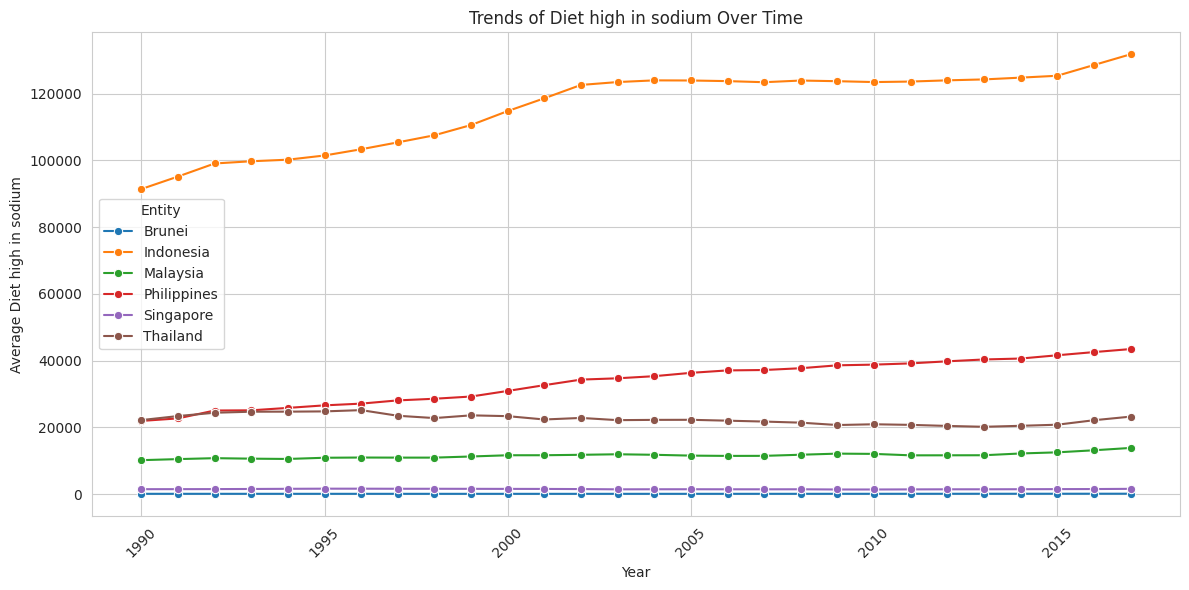

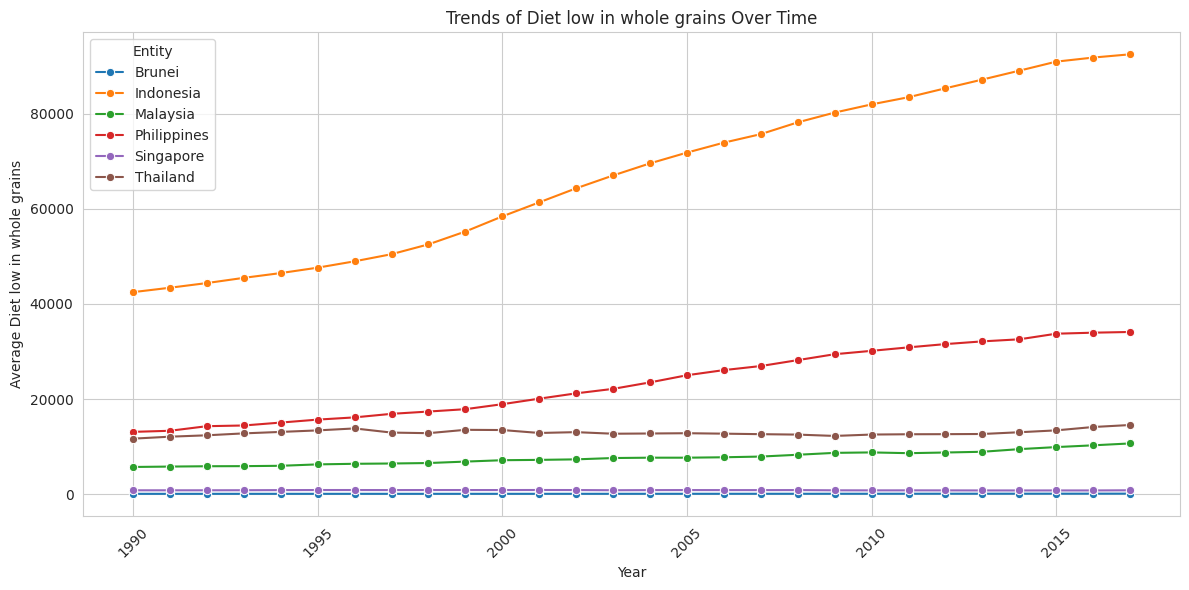

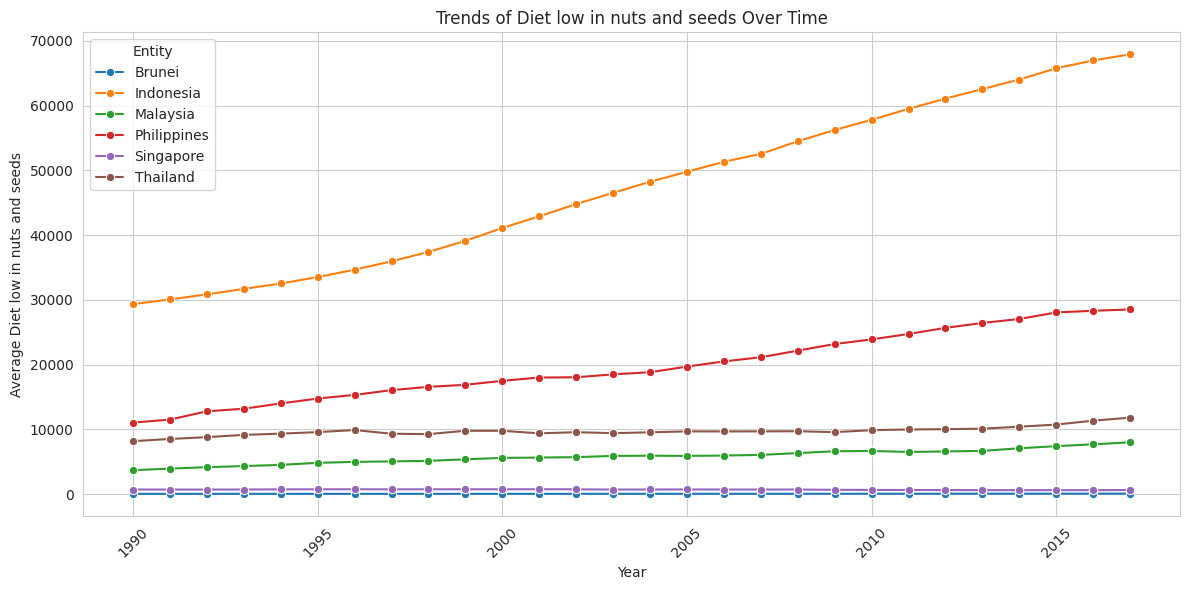

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert to Pandas for easier plotting
df_trends_pandas = df_trends.toPandas()

# Set up the figure size and seaborn style
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Plotting each risk factor for each country
for factor in risk_factors:
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_trends_pandas, x="Year", y=f"avg_{factor}", hue="Entity", marker='o')
    plt.title(f"Trends of {factor} Over Time")
    plt.xlabel("Year")
    plt.ylabel(f"Average {factor}")
    plt.legend(title="Entity")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

How does Malaysia compare to its neighbors in terms of these risk factors?

In [ ]:
# Compare Malaysia with its neighbors
# Separate Malaysia and neighbors
df_malaysia = df_filtered.filter(df_filtered["Entity"] == "Malaysia")
df_neighbors = df_filtered.filter(~df_filtered["Entity"].isin(["Malaysia"]))

# Calculate the average for Malaysia by year
df_malaysia_avg = df_malaysia.groupBy("Year").agg(
    *[F.avg(factor).alias(f"avg_{factor}_Malaysia") for factor in risk_factors]
)

# Calculate the average for neighbors by year
df_neighbors_avg = df_neighbors.groupBy("Year").agg(
    *[F.avg(factor).alias(f"avg_{factor}_Neighbors") for factor in risk_factors]
)

# Join the results to compare Malaysia with its neighbors
df_comparison = df_malaysia_avg.join(df_neighbors_avg, on="Year")

# Show the comparison for the first few years
df_comparison.show(10)

+----+--------------------------------+------------------------------+----------------------------------------------+-----------------------------------------------------+----------------------------------------+---------------------------------------+--------------------------+---------------------------+-------------------------------------------+-----------------------------+------------------------+---------------------+-------------------------------+-----------------------------------+-----------------------+----------------------------------+----------------------------------------+-----------------------------------+---------------------------------+-----------------------------------------+--------------------+----------------------------+---------------------------------+-------------------------------------+--------------------------+----------------------------------+--------------------------------+-------------------------------------+-------------------------------------

<Figure size 1200x800 with 0 Axes>

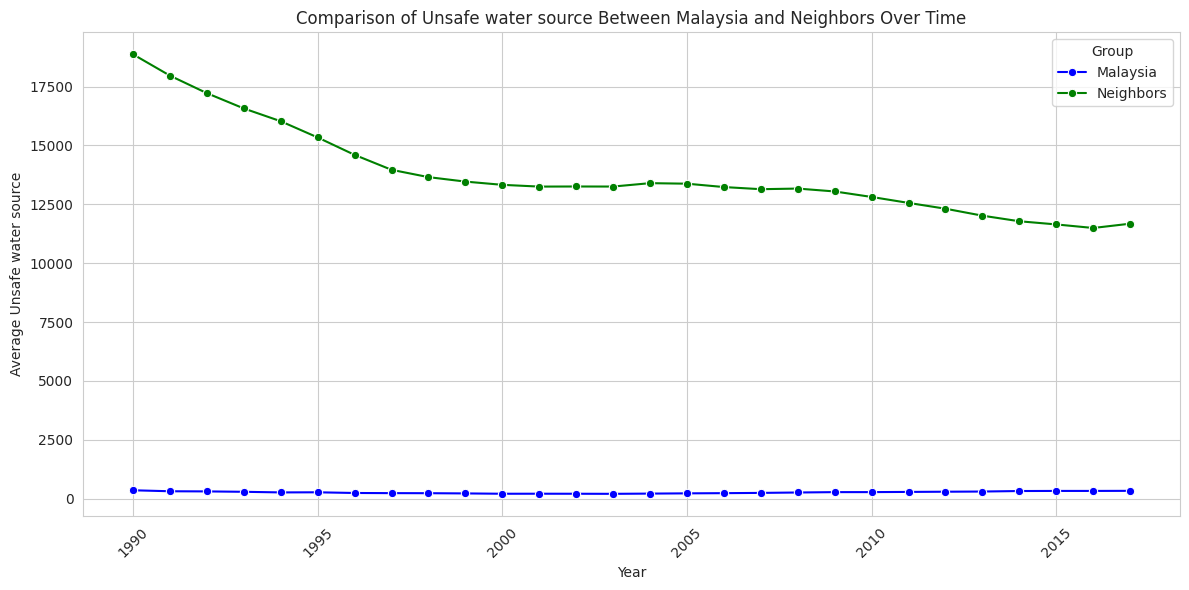

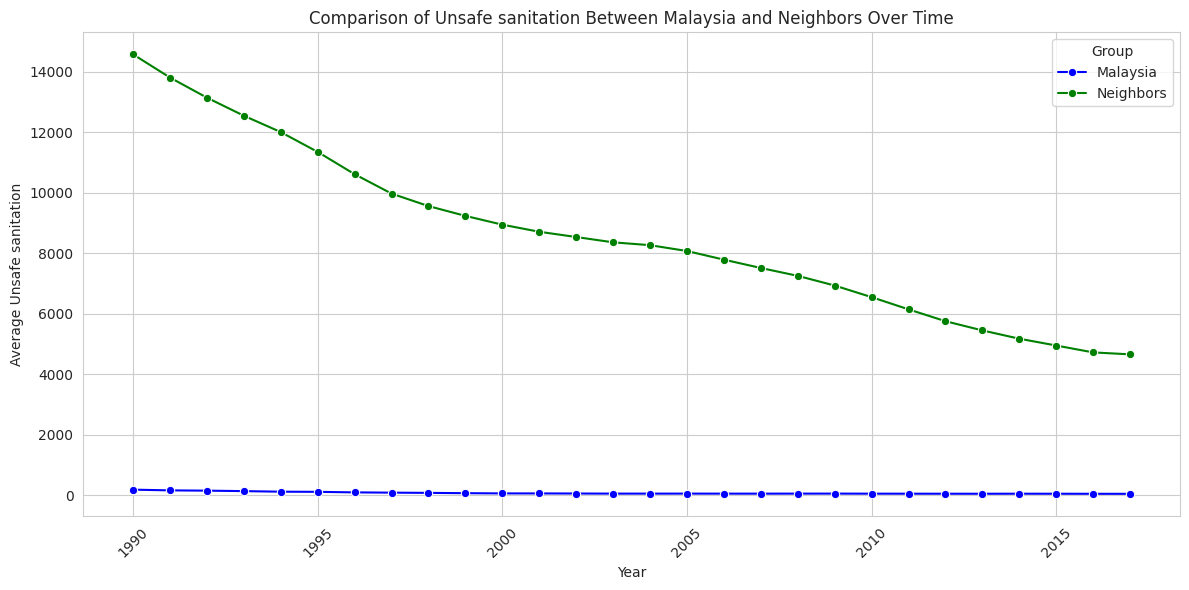

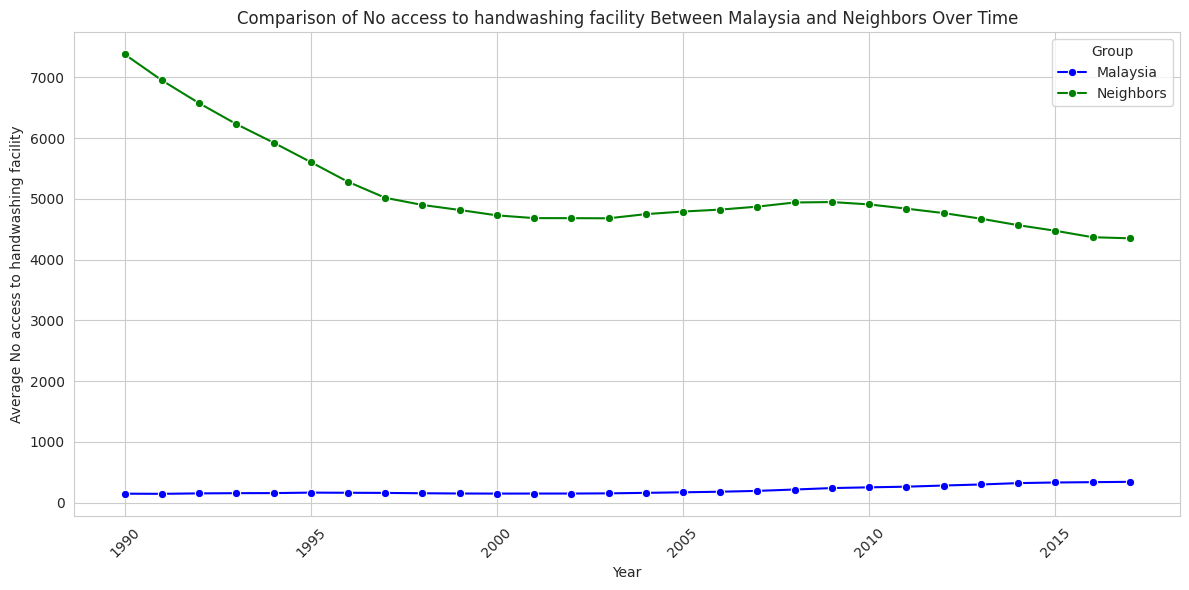

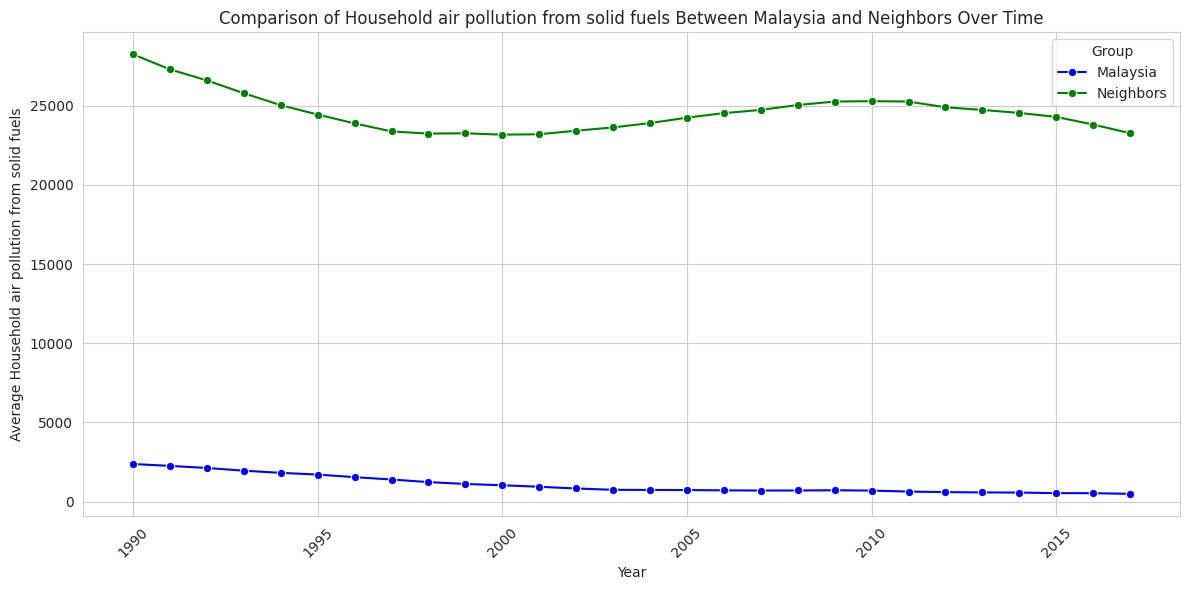

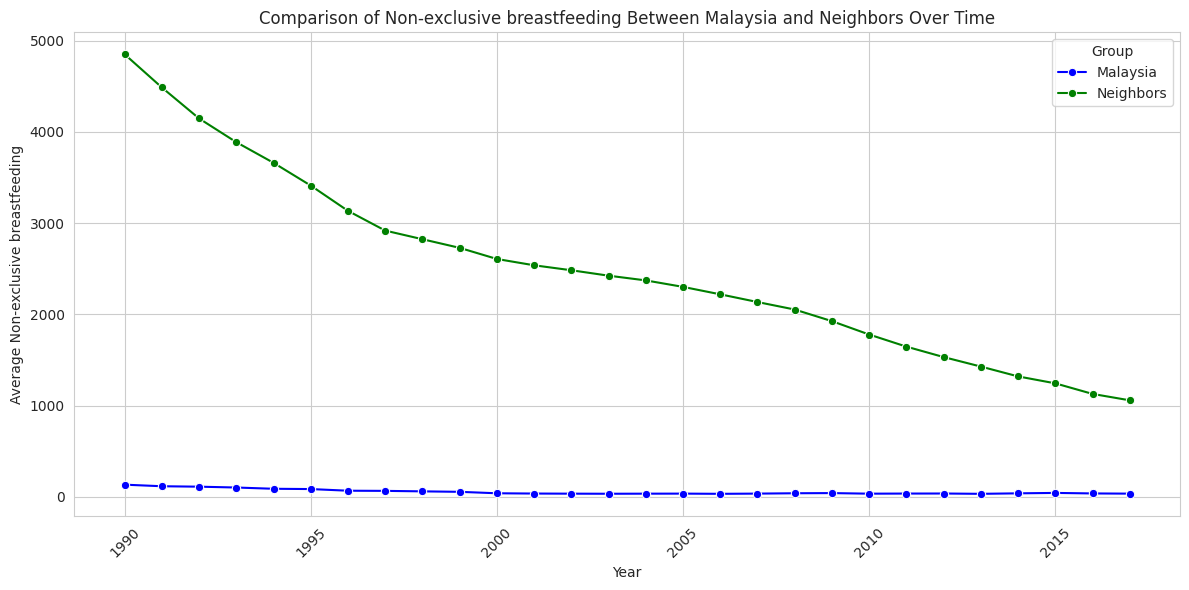

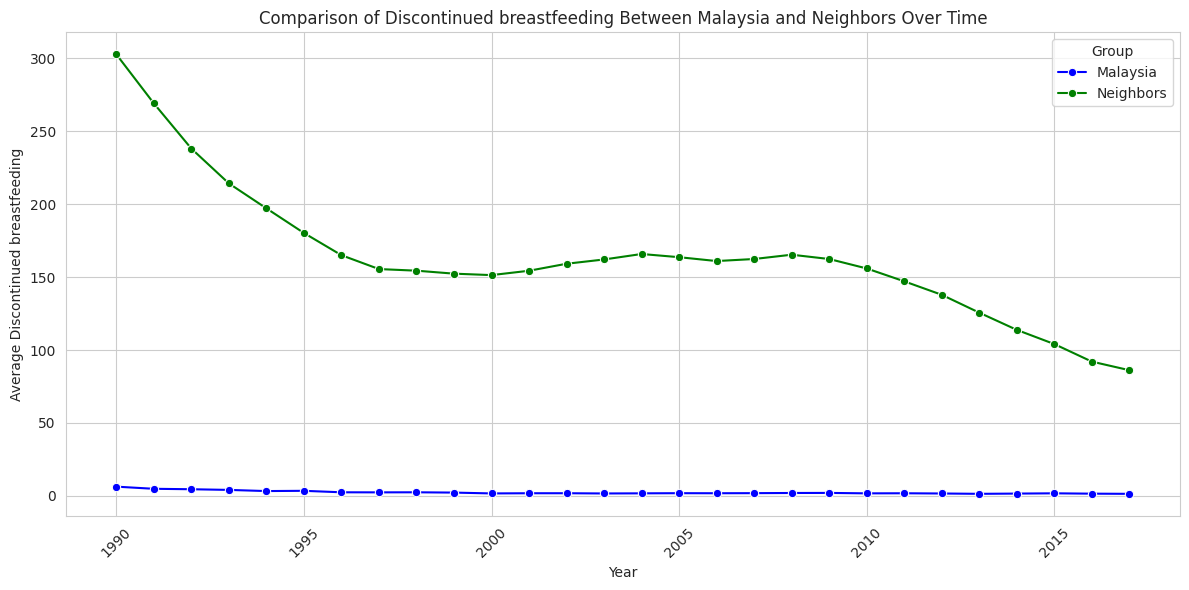

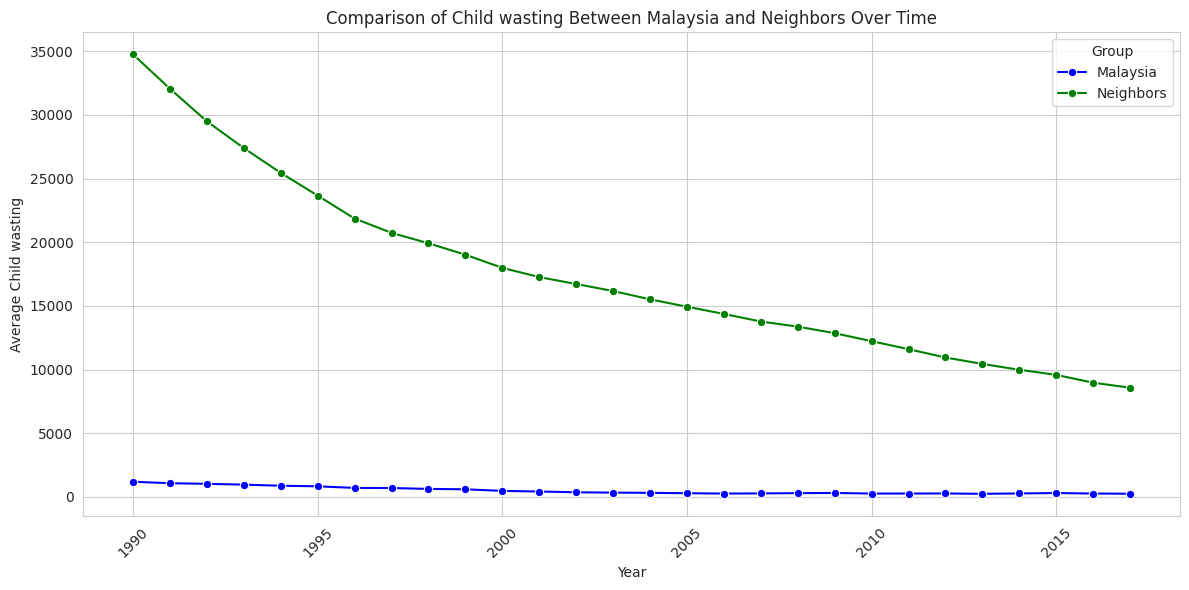

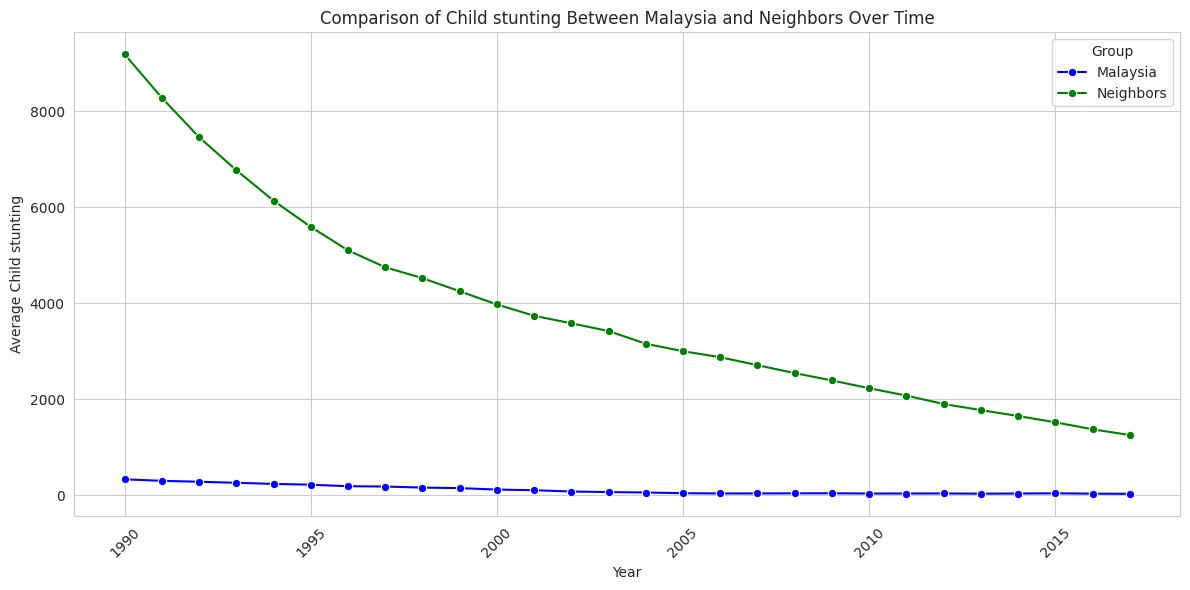

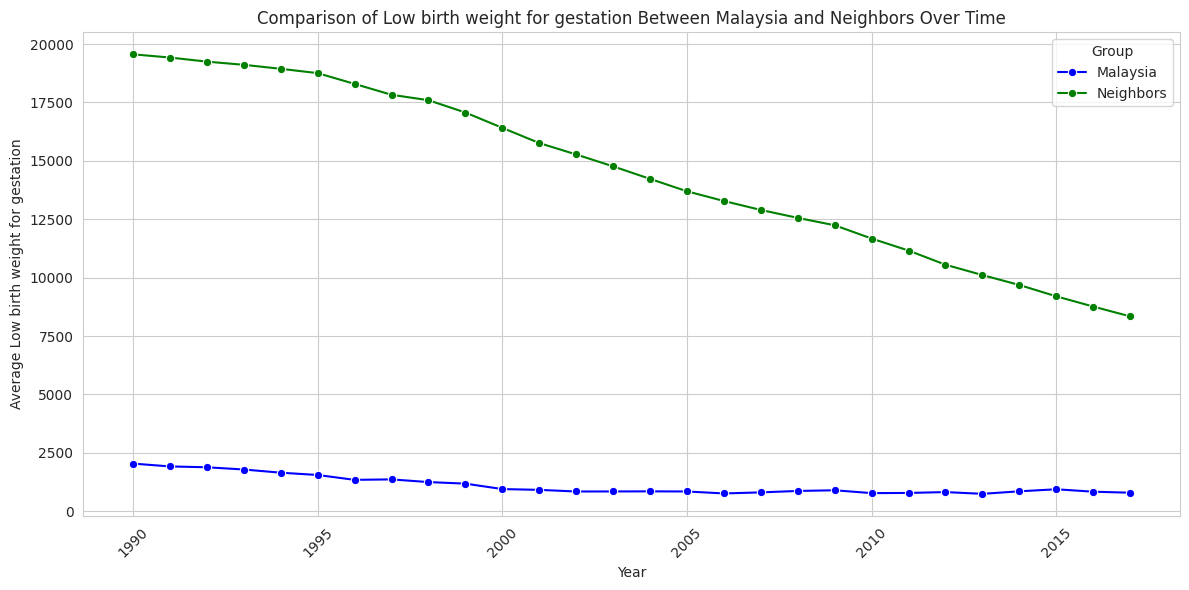

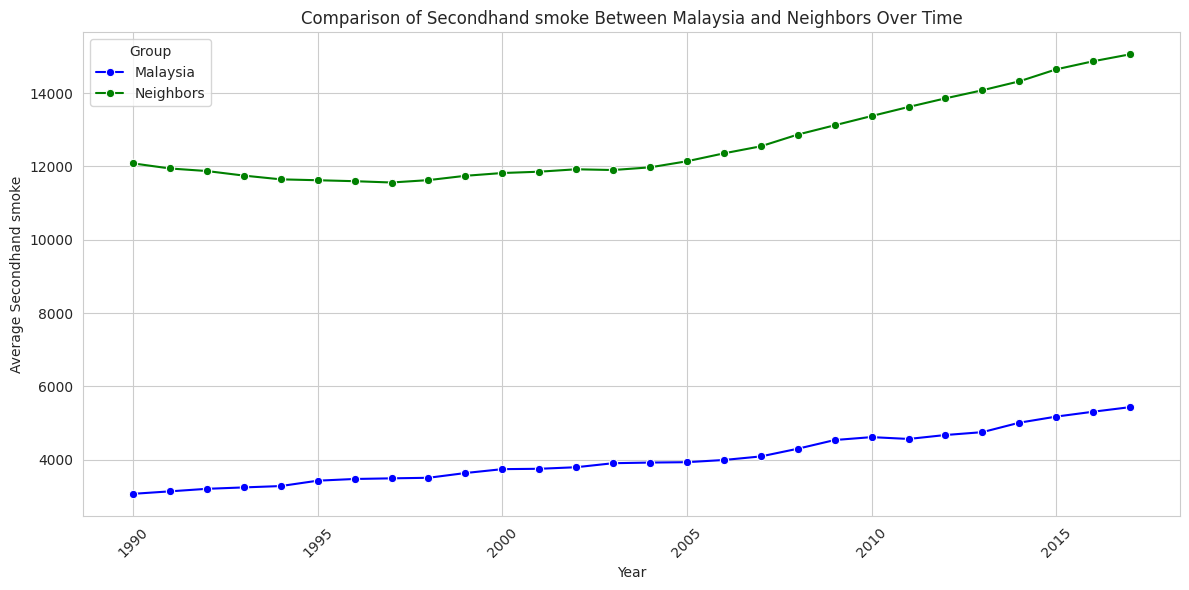

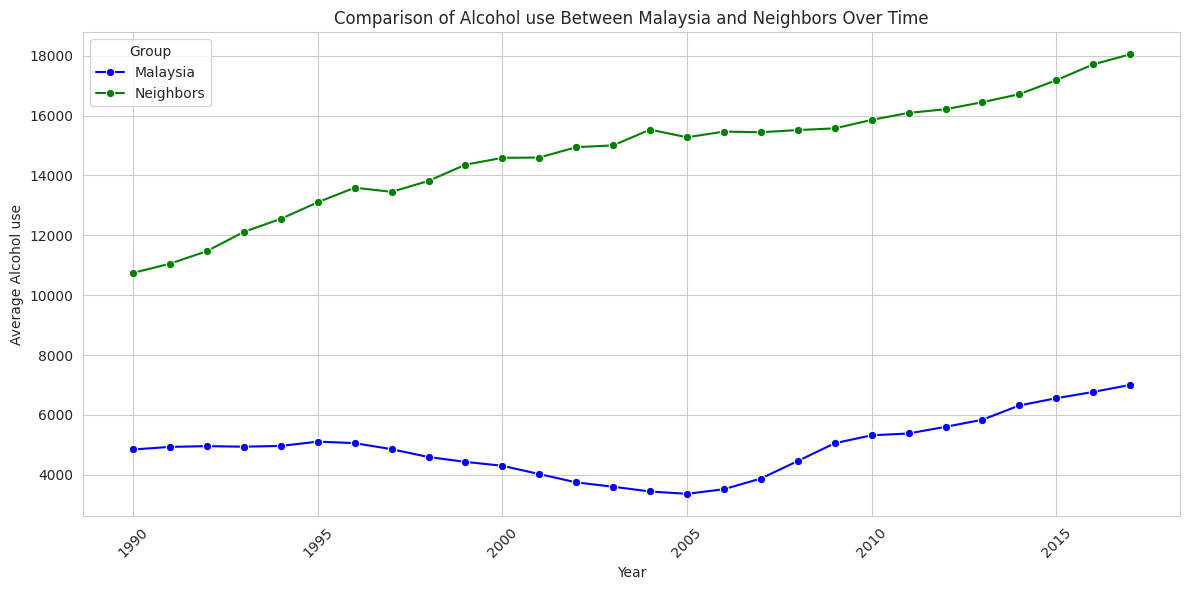

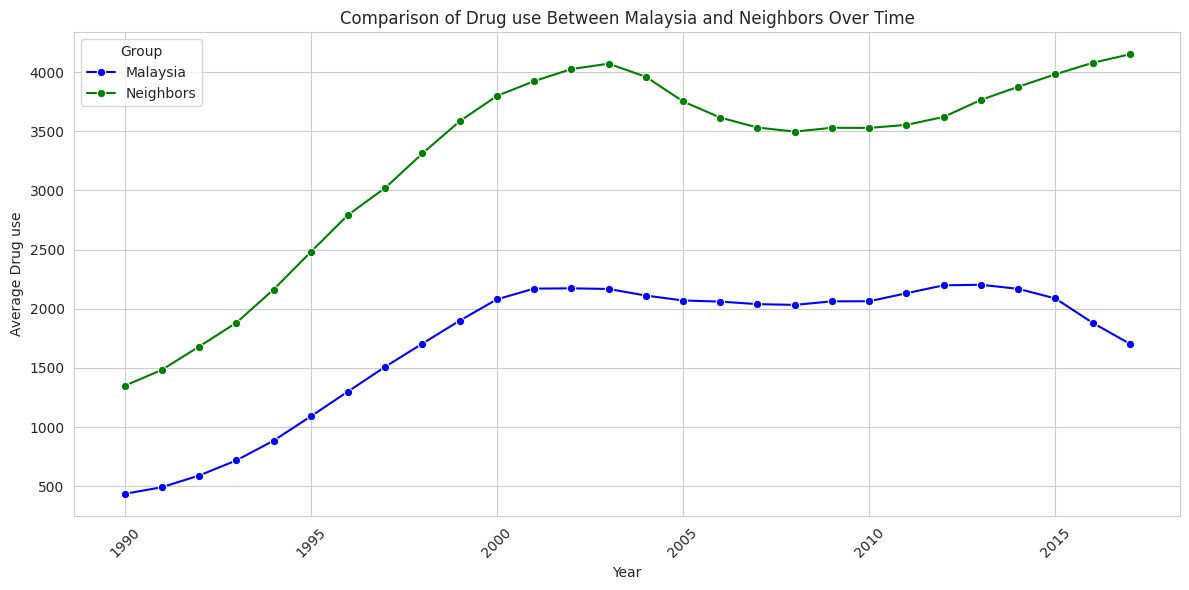

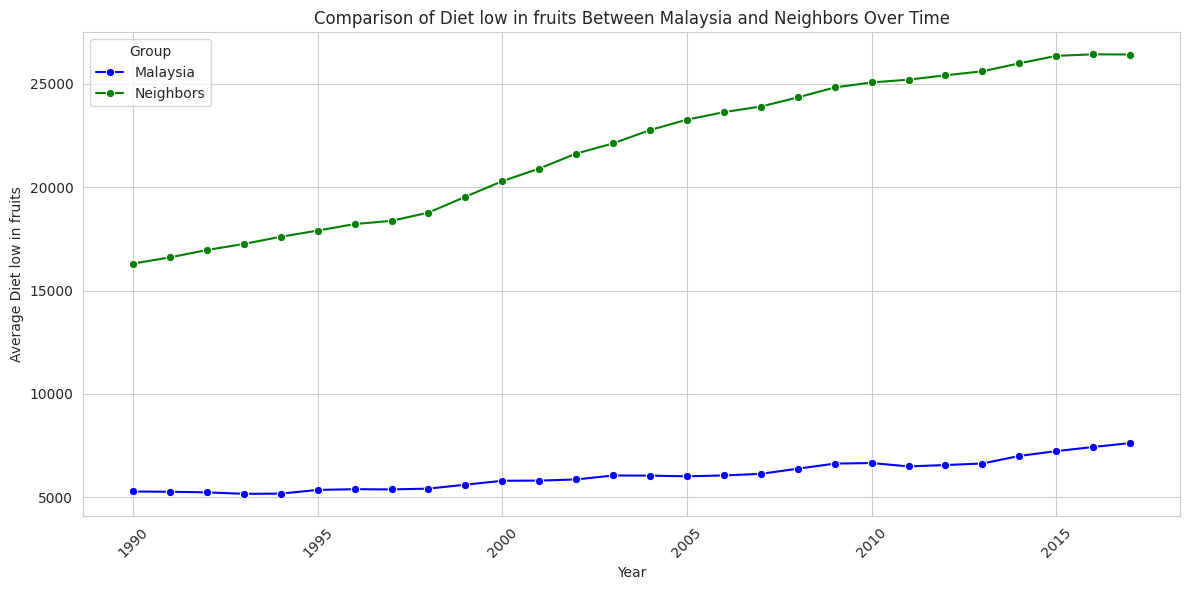

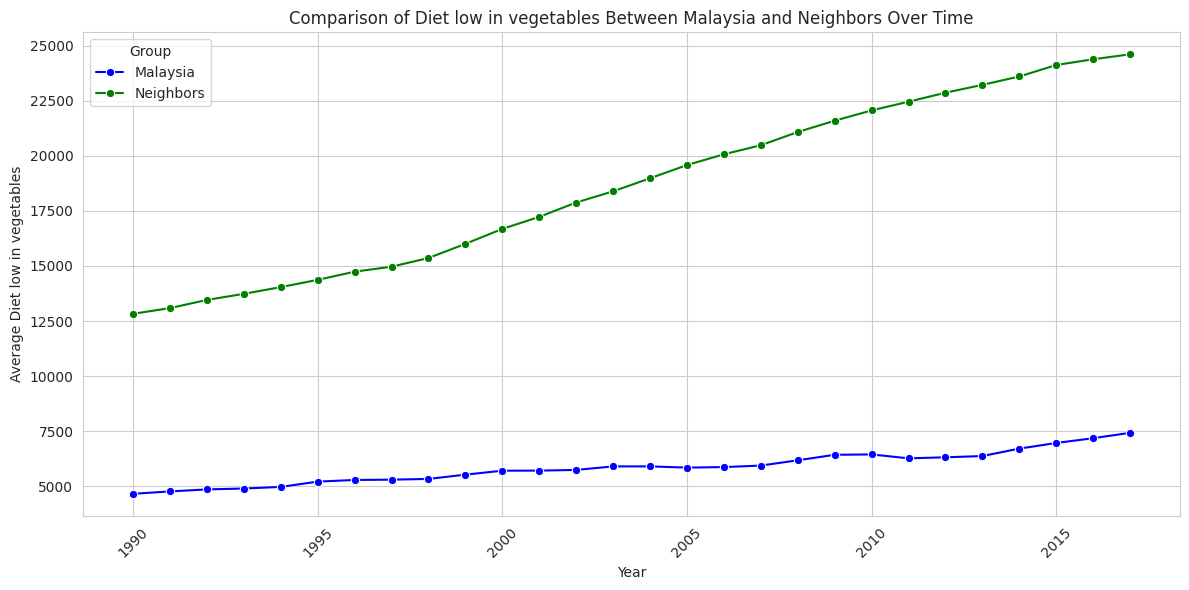

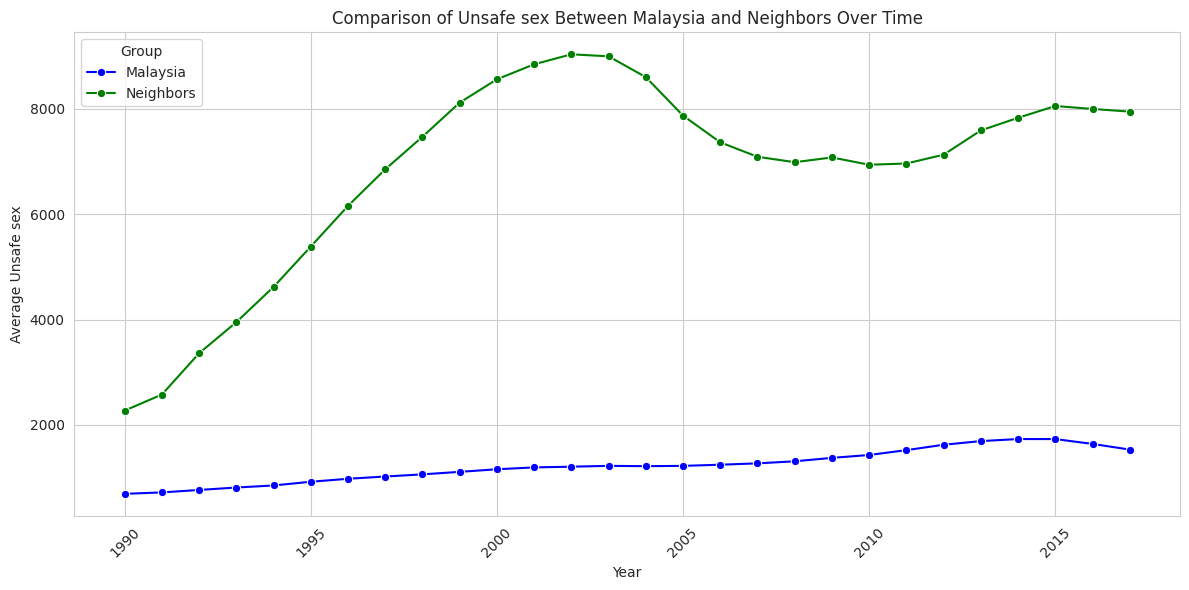

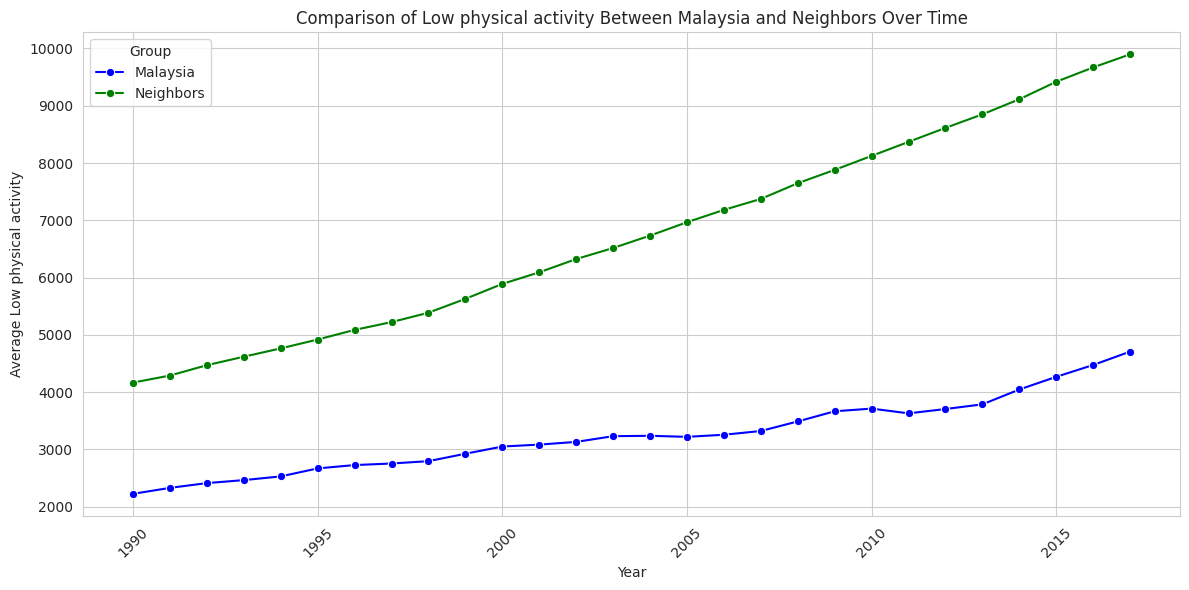

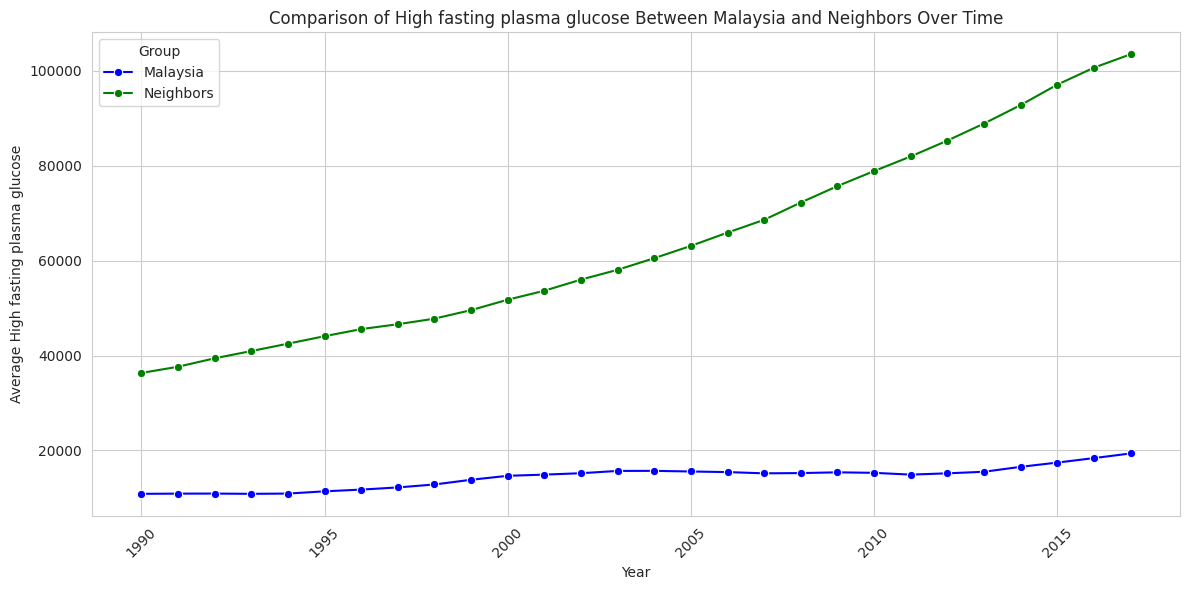

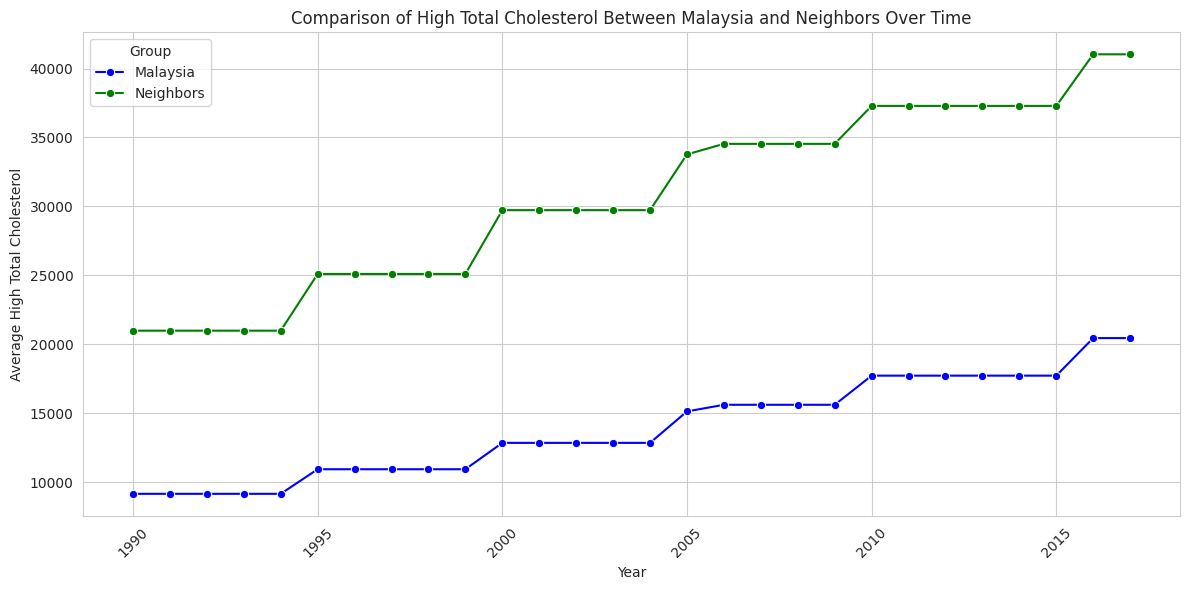

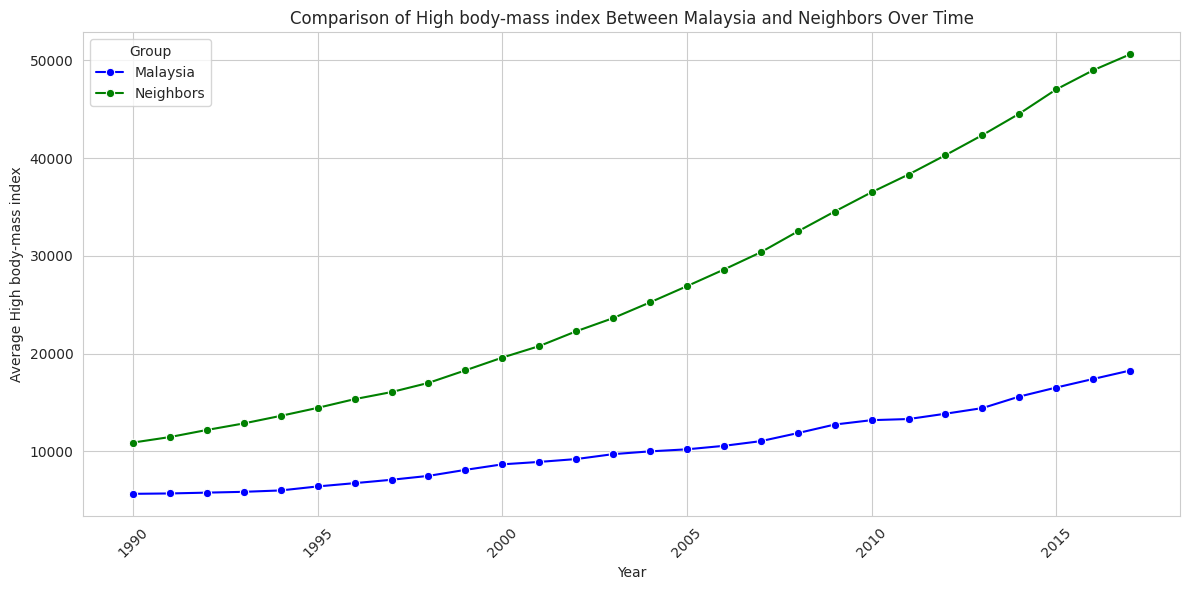

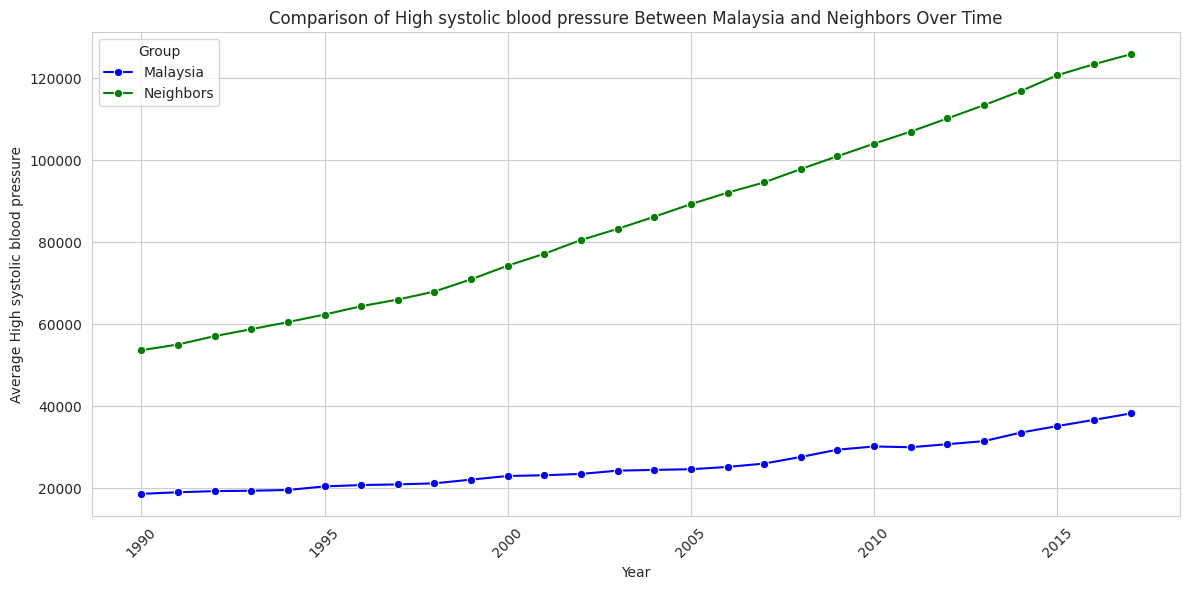

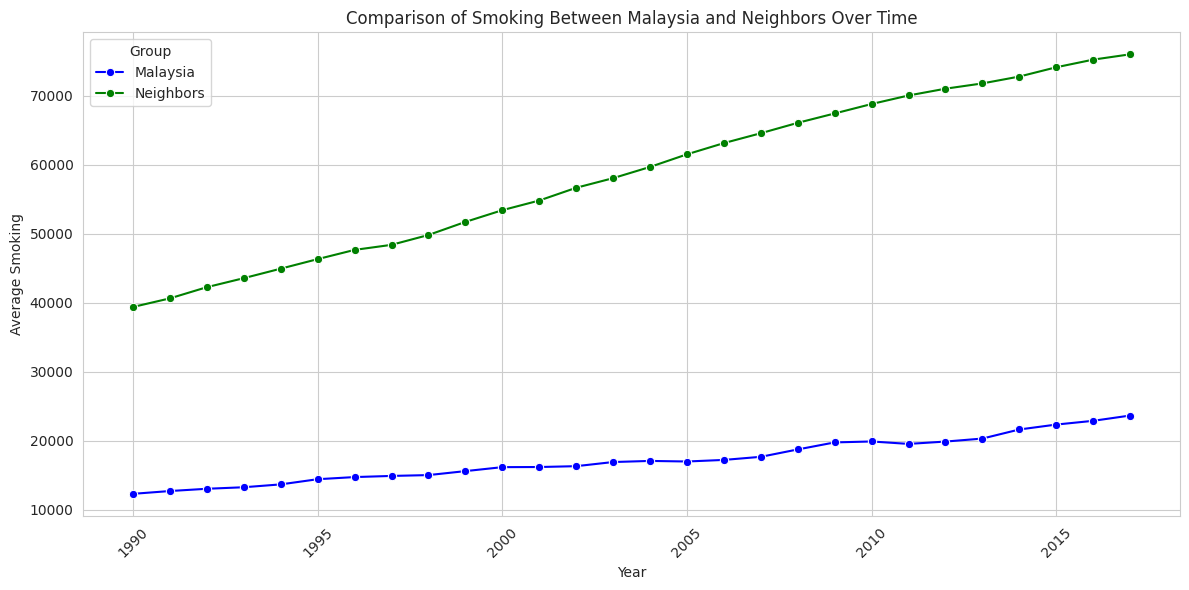

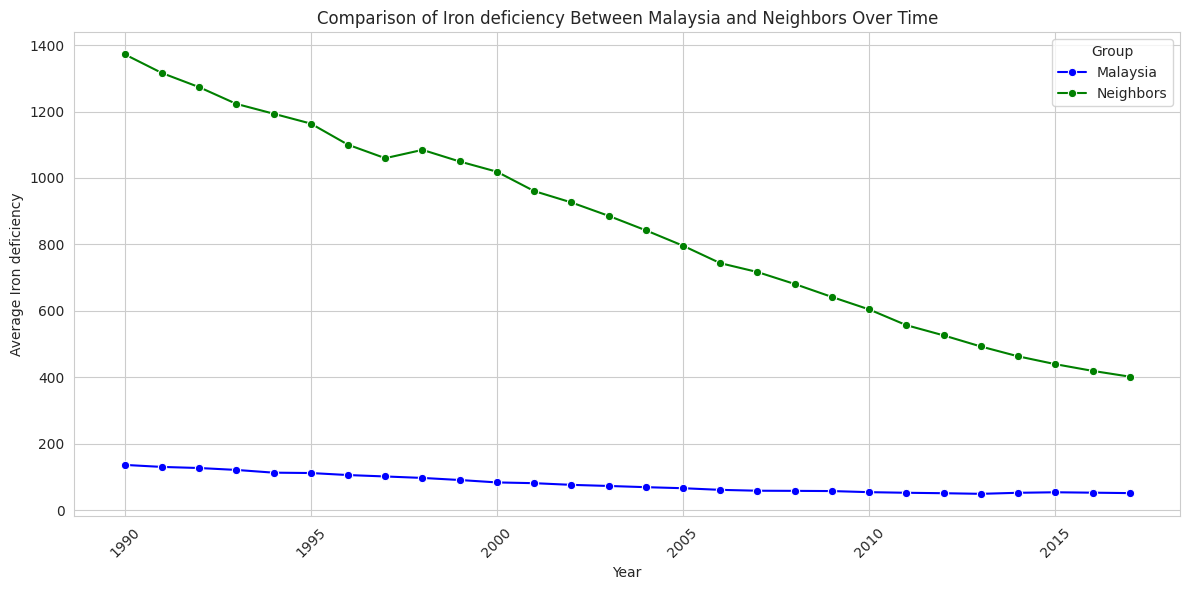

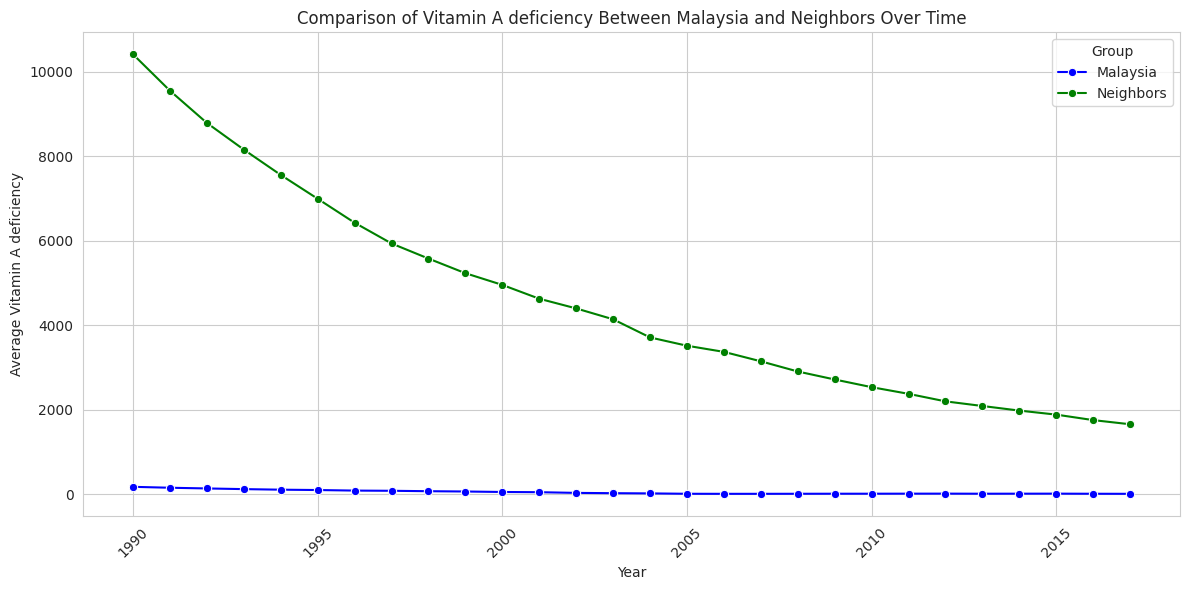

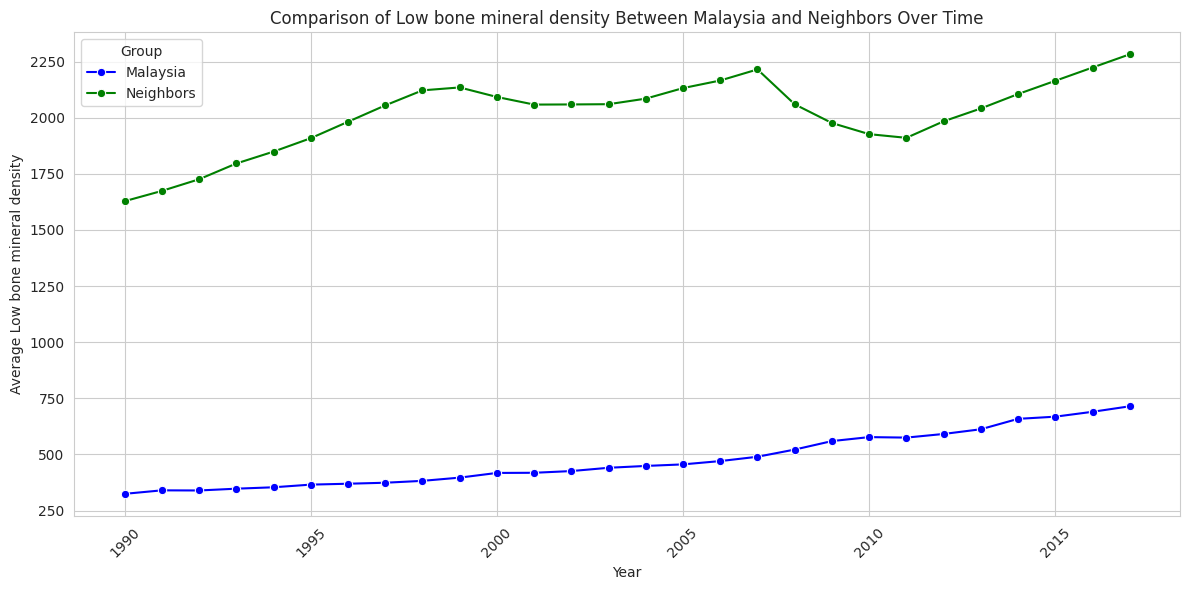

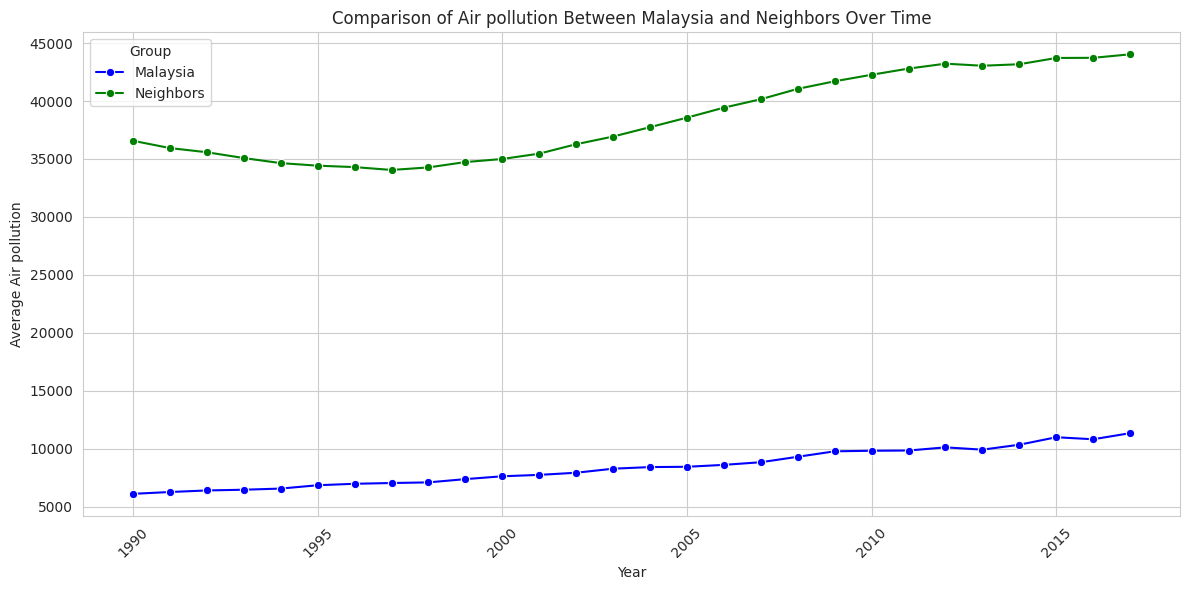

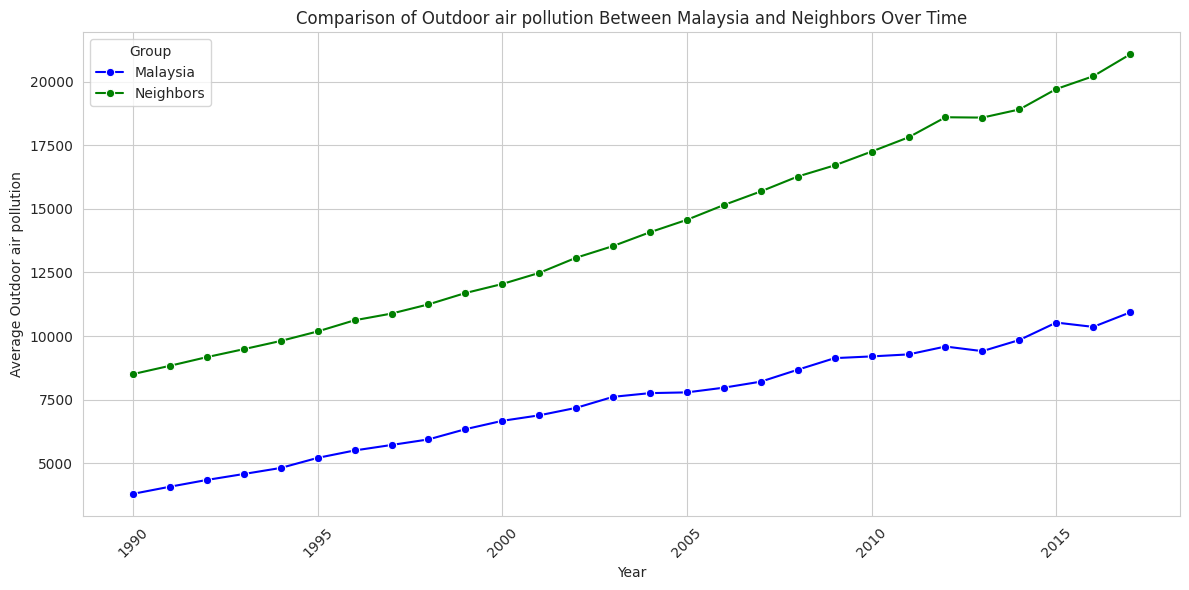

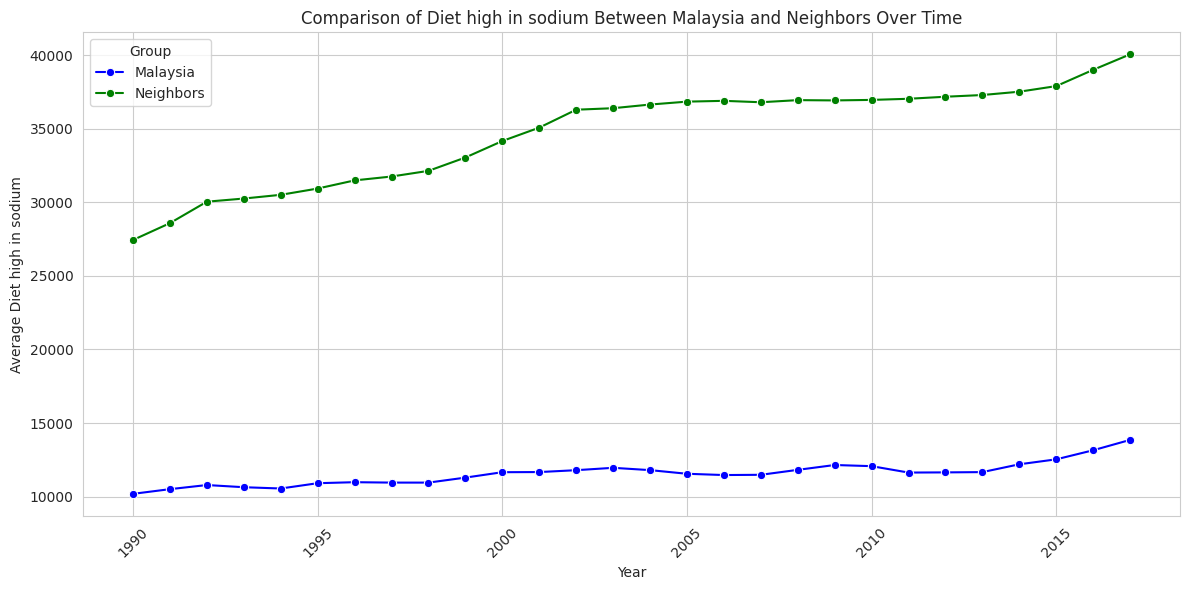

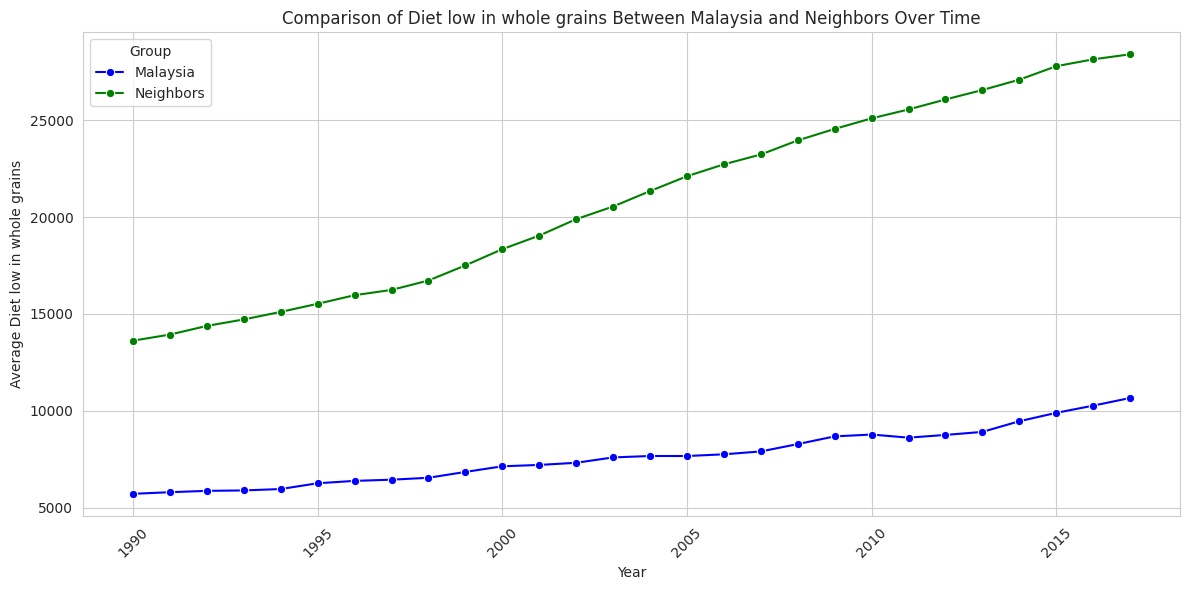

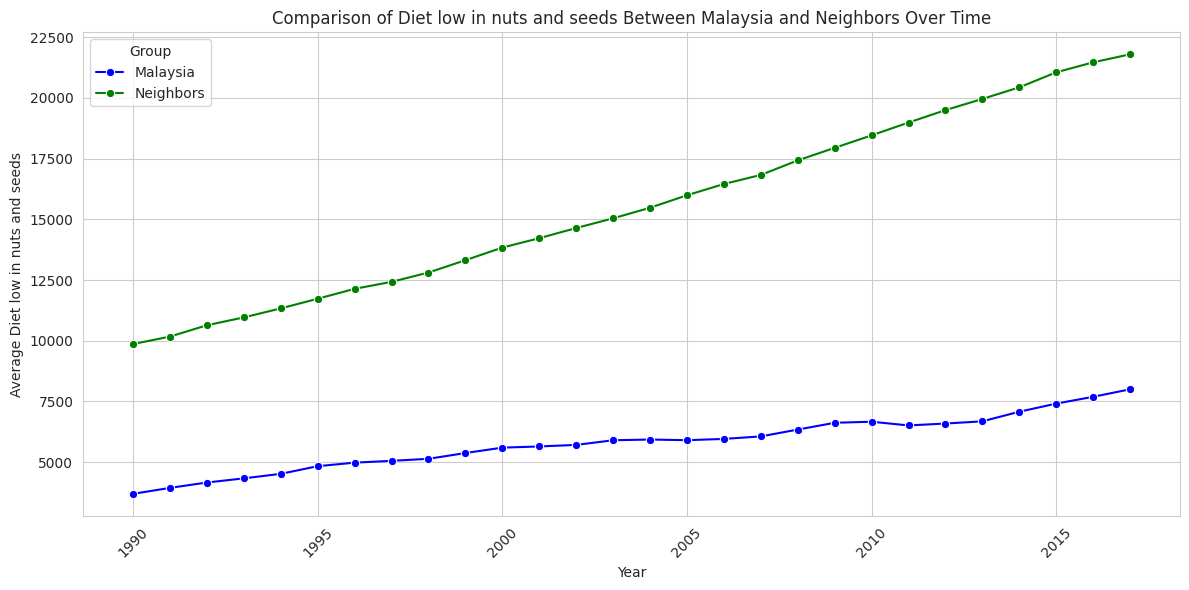

In [ ]:
# Convert to Pandas for easier plotting
df_comparison_pandas = df_comparison.toPandas()

# Set up the figure size and seaborn style
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Plotting comparison for each risk factor
for factor in risk_factors:
    plt.figure(figsize=(12, 6))

    # Plot Malaysia's trend
    sns.lineplot(data=df_comparison_pandas, x="Year", y=f"avg_{factor}_Malaysia", label="Malaysia", color='blue', marker='o')

    # Plot Neighbors' trend
    sns.lineplot(data=df_comparison_pandas, x="Year", y=f"avg_{factor}_Neighbors", label="Neighbors", color='green', marker='o')

    plt.title(f"Comparison of {factor} Between Malaysia and Neighbors Over Time")
    plt.xlabel("Year")
    plt.ylabel(f"Average {factor}")
    plt.legend(title="Group")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Is it possible to do clustering on countries with based on risk factor?

In [ ]:
from pyspark.ml.feature import StandardScaler
from pyspark.ml.feature import VectorAssembler

# Assemble all risk factors into a vector column
assembler = VectorAssembler(inputCols=risk_factors, outputCol="features")
df_vector = assembler.transform(df_filtered)

# Standardize the features (mean=0, variance=1)
scaler = StandardScaler(inputCol="features", outputCol="scaled_features")
scaler_model = scaler.fit(df_vector)
df_scaled = scaler_model.transform(df_vector)

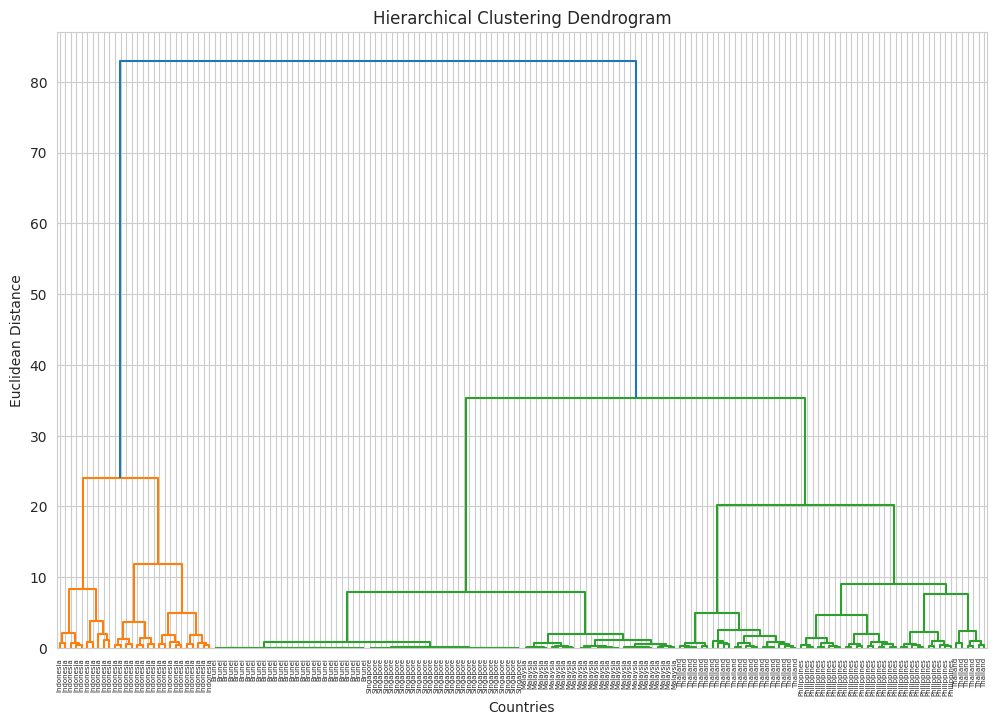

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import scipy.cluster.hierarchy as sch
import numpy as np

# Convert the data to a NumPy array for hierarchical clustering
risk_factors_data = df_scaled.select("scaled_features").rdd.map(lambda x: x[0].toArray()).collect()
risk_factors_data = np.array(risk_factors_data)

# Perform hierarchical clustering
linked = linkage(risk_factors_data, method='ward')

# Create a dendrogram
plt.figure(figsize=(12, 8))
dendrogram(linked, labels=df_filtered.select("Entity").rdd.flatMap(lambda x: x).collect(), orientation='top', distance_sort='ascending')
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Countries")
plt.ylabel("Euclidean Distance")
plt.show()

In [ ]:
from scipy.cluster.hierarchy import fcluster

# Cut the dendrogram at a certain height (e.g., 7.0) to define clusters
max_d = 7.0  # This is a threshold you can adjust based on your dendrogram
cluster_labels = fcluster(linked, max_d, criterion='distance')

# Map the cluster labels back to the original dataframe
df_filtered_with_clusters = df_filtered.withColumn("cluster", F.array(*[F.lit(cluster_labels[i]) for i in range(len(cluster_labels))]))

# Show the countries and their assigned clusters
df_filtered_with_clusters.show()


+------+----+-------------------+-----------------+---------------------------------+----------------------------------------+---------------------------+--------------------------+-------------+--------------+------------------------------+----------------+-----------+-----------+------------------+----------------------+-----------+---------------------+---------------------------+----------------------+--------------------+----------------------------+-----------+---------------+--------------------+------------------------+-------------+---------------------+-------------------+------------------------+--------------------------+--------------------+
|Entity|Year|Unsafe water source|Unsafe sanitation|No access to handwashing facility|Household air pollution from solid fuels|Non-exclusive breastfeeding|Discontinued breastfeeding|Child wasting|Child stunting|Low birth weight for gestation|Secondhand smoke|Alcohol use|   Drug use|Diet low in fruits|Diet low in vegetables| Unsafe sex|L

In [ ]:
from pyspark.sql import functions as F

# Calculate the average risk factors per cluster
cluster_avg_risk_factors = df_filtered_with_clusters.groupBy("cluster").agg(
    *[F.avg(factor).alias(f"avg_{factor}") for factor in risk_factors]
)

cluster_avg_risk_factors.show()


+--------------------+-----------------------+---------------------+-------------------------------------+--------------------------------------------+-------------------------------+------------------------------+------------------+------------------+----------------------------------+--------------------+------------------+------------------+----------------------+--------------------------+-----------------+-------------------------+-------------------------------+--------------------------+------------------------+--------------------------------+------------------+-------------------+------------------------+----------------------------+------------------+-------------------------+-----------------------+----------------------------+------------------------------+
|             cluster|avg_Unsafe water source|avg_Unsafe sanitation|avg_No access to handwashing facility|avg_Household air pollution from solid fuels|avg_Non-exclusive breastfeeding|avg_Discontinued breastfeeding| avg_C

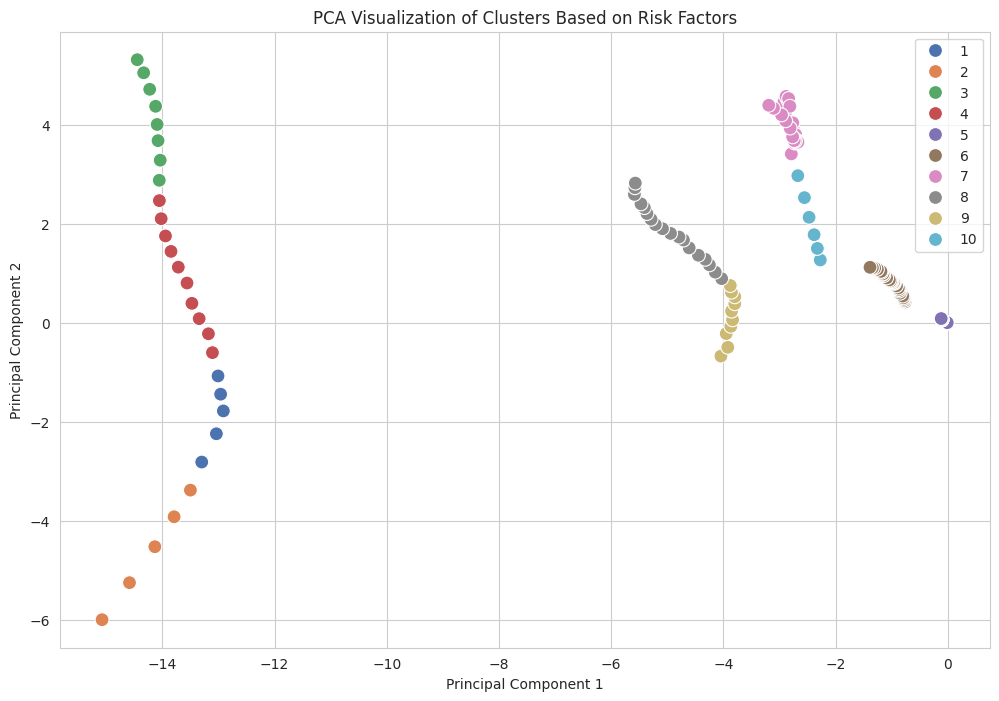

In [ ]:
from pyspark.ml.feature import PCA

# Apply PCA to reduce the dimensions of the data
pca = PCA(k=2, inputCol="scaled_features", outputCol="pca_features")
pca_model = pca.fit(df_scaled)
df_pca = pca_model.transform(df_scaled)

# Convert PCA features to pandas DataFrame for plotting
df_pca_pd = df_pca.select("Entity", "pca_features").toPandas()
df_pca_pd[['pca1', 'pca2']] = pd.DataFrame(df_pca_pd['pca_features'].to_list(), index=df_pca_pd.index)

# Add the cluster labels
df_pca_pd['cluster'] = cluster_labels

# Plot the clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_pca_pd, x='pca1', y='pca2', hue='cluster', palette="deep", s=100)
plt.title("PCA Visualization of Clusters Based on Risk Factors")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()